In [1]:
from pathlib import Path
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
from scipy import optimize

try:
    import cvxpy as cp
except Exception:
    cp = None

from cycler import cycler

from IPython.display import display

from quantfinlab.portfolio import (
    prices_to_returns,
    make_rebalance_dates,
    estimate_covariance,
    make_psd,
    equal_weight,
    momentum_mu,
    minimum_variance,
    mean_variance,
    max_sharpe_frontier_grid)
from quantfinlab.risk import (
    corr_matrix,
    rolling_volatility,
    drawdown_summary_table,
    stress_table,
    var_es_table,
    var_backtest_table,
    best_var_methods,
    rolling_var,
)
from quantfinlab.plotting import (
    plot_corr_heatmap,
    plot_strategy_nav,
    plot_strategy_drawdowns,
    plot_stress_bar,
)
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.reports.risk_report import risk_report

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
           "#9614fa", "#DC143C", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
if cycler is not None:
    plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (7, 3.5),
    "figure.dpi": 140,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8})

start_date = "2013-01-01"
end_date = None
annualization = 252
rebal_freq = "ME"
cov_lookback = 756
mu_lookback = 252
conf_lookback_months = 36
view_horizon_days = 21
ewma_lambda = 0.97
tau = 0.05
cost_bps = 10.0
w_min = 0.0
w_max = 0.25
bl_mv_lambda = 6.0
delta_fallback = 2.5
delta_min = 0.50
delta_max = 8.00
view_q_max = 0.06
view_entry_z = 0.50
max_active_views = 8
max_active_selected_views = 5
view_tilt_max = 0.040
view_tilt_max_systematic = 0.025
family_q_caps = {
    "equity_duration_risk_on": 0.035,
    "growth_leadership": 0.025,
    "large_quality_vs_cyclicals": 0.025,
    "short_duration_bond_defense": 0.020,
    "duration_recovery": 0.018,
    "inflation_vs_duration": 0.018,
    "credit_risk_confirmation": 0.012,
}
use_empirical_omega_rescale = False
active_weight_limit = 0.20
active_weight_relaxed = 0.30
gamma_te = 3.0
active_te_target = 0.05
risk_control_active_weight_limit = 0.06
risk_control_active_distance_target = 0.15
risk_control_active_te_target = 0.02
conf_floor = 0.20
conf_cap = 0.85
haircut_conf_floor = 0.20
haircut_conf_cap = 0.85
force_download = False
risk_free_daily = 0.0
data_dir = Path("data/raw/yfinance")
data_dir.mkdir(parents=True, exist_ok=True)

sleeve_map = {
    "SPY": "US equity", "QQQ": "US equity", "IWM": "US equity",
    "EFA": "International equity", "EEM": "International equity",
    "TLT": "Duration bonds", "IEF": "Duration bonds", "SHY": "Short bonds",
    "AGG": "Core bonds", "LQD": "Credit", "HYG": "Credit",
    "GLD": "Real assets", "VNQ": "Real assets", "DBC": "Commodities",
    "UUP": "Dollar"}


In [2]:
data_path = Path("../data/ETF_data.csv")
if not data_path.exists():
    data_path = Path("data/ETF_data.csv")
raw = pd.read_csv(data_path)
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw = raw.dropna(subset=["date"]).sort_values("date")
raw = raw.drop_duplicates(subset=["date"], keep="last")
raw = raw.set_index("date")

close_cols = [col for col in raw.columns if str(col).endswith("__close")]
volume_cols = [col for col in raw.columns if str(col).endswith("__volume")]
dividend_cols = [col for col in raw.columns if str(col).endswith("__dividends")]
split_cols = [col for col in raw.columns if str(col).endswith("__stock_splits")]

close_all = raw[close_cols].copy()
close_all.columns = [col.rsplit("__", 1)[0] for col in close_cols]
close_all = close_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
close_all = close_all.dropna(axis=1, how="all").reindex(columns=sorted(close_all.columns))

volume_all = raw[volume_cols].copy()
volume_all.columns = [col.rsplit("__", 1)[0] for col in volume_cols]
volume_all = volume_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
volume_all = volume_all.dropna(axis=1, how="all").reindex(columns=sorted(volume_all.columns))

dividends_all = raw[dividend_cols].copy()
dividends_all.columns = [col.rsplit("__", 1)[0] for col in dividend_cols]
dividends_all = dividends_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
dividends_all = dividends_all.reindex(columns=sorted(dividends_all.columns))

splits_all = raw[split_cols].copy()
splits_all.columns = [col.rsplit("__", 1)[0] for col in split_cols]
splits_all = splits_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
splits_all = splits_all.reindex(columns=sorted(splits_all.columns))

action_parts = []
if not dividends_all.empty:
    dividends_part = dividends_all.copy()
    dividends_part.columns = pd.MultiIndex.from_product([dividends_part.columns, ["dividends"]])
    action_parts.append(dividends_part)
if not splits_all.empty:
    splits_part = splits_all.copy()
    splits_part.columns = pd.MultiIndex.from_product([splits_part.columns, ["stock_splits"]])
    action_parts.append(splits_part)
actions_all = pd.concat(action_parts, axis=1).sort_index(axis=1) if action_parts else pd.DataFrame(index=raw.index)

print("data file:", data_path)
print("close panel:", close_all.shape, close_all.index.min().date(), "to", close_all.index.max().date())
print("auto_adjust=True in the data script, so close is the adjusted price input used below")
print("volume panel:", volume_all.shape)


data file: ..\data\ETF_data.csv
close panel: (4107, 56) 2010-01-04 to 2026-05-01
auto_adjust=True in the data script, so close is the adjusted price input used below
volume panel: (4107, 56)


In [3]:
def missing_after_first_valid(series):
    first = series.first_valid_index()
    if first is None:
        return np.nan
    return float(series.loc[first:].isna().mean())

assets = [
    "SPY", "QQQ", "IWM",
    "EFA", "EEM",
    "TLT", "IEF", "SHY", "AGG",
    "LQD", "HYG",
    "GLD", "VNQ", "DBC",
]
signal_only_assets = ["UUP"] if "UUP" in close_all.columns else []
close_after_start = close_all.loc[pd.Timestamp(start_date):].copy()
missing_assets = [ticker for ticker in assets if ticker not in close_after_start.columns]
if missing_assets:
    raise ValueError(f"missing required tradable adjusted close columns: {missing_assets}")

filter_rows = []
for ticker in assets + signal_only_assets:
    px = close_after_start[ticker]
    valid = px.dropna()
    filter_rows.append({"ticker": ticker, "observations": len(valid), "first_date": valid.index.min() if len(valid) else pd.NaT, "last_date": valid.index.max() if len(valid) else pd.NaT, "missing_pct_after_first_valid": missing_after_first_valid(px), "tradable": ticker in assets})
display(pd.DataFrame(filter_rows).round(4))

first_all_valid = close_after_start[assets].dropna(how="any").index.min()
if pd.isna(first_all_valid):
    raise ValueError("no date where all tradable ETF close columns are available")
close_raw = close_after_start.loc[first_all_valid:, assets]
close = close_raw.ffill(limit=3).dropna(how="any")
returns = prices_to_returns(close, kind="simple").replace([np.inf, -np.inf], np.nan).dropna(how="all")
remaining_return_gaps = int(returns.isna().sum().sum())
if remaining_return_gaps:
    print(f"filling {remaining_return_gaps} isolated post-inception return gaps with 0.0 after adjusted-price cleaning")
returns_p6 = returns.fillna(0.0)
close_p6 = close.reindex(returns_p6.index).ffill(limit=3)
returns = returns_p6

signal_tickers = list(dict.fromkeys(assets + signal_only_assets))
signal_close = close_after_start.loc[first_all_valid:, signal_tickers].ffill(limit=3).reindex(returns_p6.index).ffill(limit=3)
signal_returns = signal_close.pct_change().replace([np.inf, -np.inf], np.nan).reindex(returns_p6.index).fillna(0.0)

print("assets:", assets)
print("signal assets:", list(signal_returns.columns))
print("return panel:", returns_p6.shape, returns_p6.index.min().date(), "to", returns_p6.index.max().date())


,ticker,observations,first_date,last_date,missing_pct_after_first_valid,tradable
0,SPY,3353,2013-01-02,2026-05-01,0.0,True
1,QQQ,3353,2013-01-02,2026-05-01,0.0,True
2,IWM,3353,2013-01-02,2026-05-01,0.0,True
3,EFA,3353,2013-01-02,2026-05-01,0.0,True
4,EEM,3353,2013-01-02,2026-05-01,0.0,True
5,TLT,3353,2013-01-02,2026-05-01,0.0,True
6,IEF,3353,2013-01-02,2026-05-01,0.0,True
7,SHY,3353,2013-01-02,2026-05-01,0.0,True
8,AGG,3353,2013-01-02,2026-05-01,0.0,True
9,LQD,3353,2013-01-02,2026-05-01,0.0,True


assets: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'IEF', 'SHY', 'AGG', 'LQD', 'HYG', 'GLD', 'VNQ', 'DBC']
signal assets: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'IEF', 'SHY', 'AGG', 'LQD', 'HYG', 'GLD', 'VNQ', 'DBC', 'UUP']
return panel: (3352, 14) 2013-01-03 to 2026-05-01


In [4]:
rebalance_dates = make_rebalance_dates(returns_p6.index, freq=rebal_freq, min_history_days=max(cov_lookback, mu_lookback, 756))
print("rebalance dates:", len(rebalance_dates))
print("first:", rebalance_dates[0].date(), "last:", rebalance_dates[-1].date())


rebalance dates: 125
first: 2016-01-29 last: 2026-05-01


In [5]:
def max_drawdown_from_nav(nav):
    nav = pd.Series(nav).dropna()
    if nav.empty:
        return np.nan
    return float((nav / nav.cummax() - 1.0).min())

rows = []
for ticker in assets:
    px = close_p6[ticker].dropna()
    ret = returns_p6[ticker].dropna()
    years = max(len(ret) / annualization, 1e-9)
    nav = (1.0 + ret).cumprod()
    rows.append({
        "ticker": ticker,
        "sleeve": sleeve_map.get(ticker, "Other"),
        "first_date": px.index.min(),
        "last_date": px.index.max(),
        "observations": int(px.shape[0]),
        "ann_return": float(nav.iloc[-1] ** (1.0 / years) - 1.0) if len(nav) else np.nan,
        "ann_vol": float(ret.std() * math.sqrt(annualization)) if len(ret) else np.nan,
        "max_drawdown": max_drawdown_from_nav(nav),
    })
table = pd.DataFrame(rows).sort_values("ticker")
display(table.round({"ann_return": 4, "ann_vol": 4, "max_drawdown": 4}))


,ticker,sleeve,first_date,last_date,observations,ann_return,ann_vol,max_drawdown
8,AGG,Core bonds,2013-01-03,2026-05-01,3352,0.0178,0.0496,-0.1843
13,DBC,Commodities,2013-01-03,2026-05-01,3352,0.0203,0.1702,-0.6220
4,EEM,International equity,2013-01-03,2026-05-01,3352,0.0492,0.2015,-0.3982
3,EFA,International equity,2013-01-03,2026-05-01,3352,0.0746,0.1670,-0.3419
11,GLD,Real assets,2013-01-03,2026-05-01,3352,0.0743,0.1630,-0.3860
10,HYG,Credit,2013-01-03,2026-05-01,3352,0.0414,0.0790,-0.2203
6,IEF,Duration bonds,2013-01-03,2026-05-01,3352,0.0120,0.0645,-0.2408
2,IWM,US equity,2013-01-03,2026-05-01,3352,0.1061,0.2154,-0.4113
9,LQD,Credit,2013-01-03,2026-05-01,3352,0.0256,0.0798,-0.2510
1,QQQ,US equity,2013-01-03,2026-05-01,3352,0.1992,0.2078,-0.3512


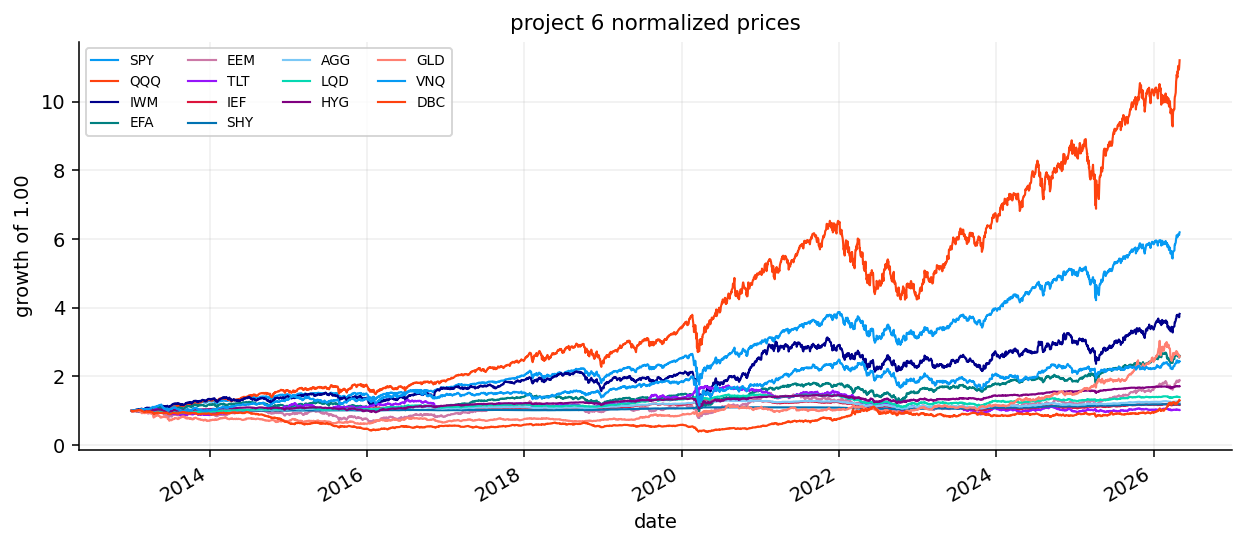

In [6]:
normalized_prices = close / close.ffill().bfill().iloc[0]
ax = normalized_prices.plot(figsize=(9, 4), lw=1.1)
ax.set_title("project 6 normalized prices")
ax.set_ylabel("growth of 1.00")
ax.set_xlabel("date")
ax.legend(ncol=4, fontsize=7)
plt.tight_layout()
plt.show()


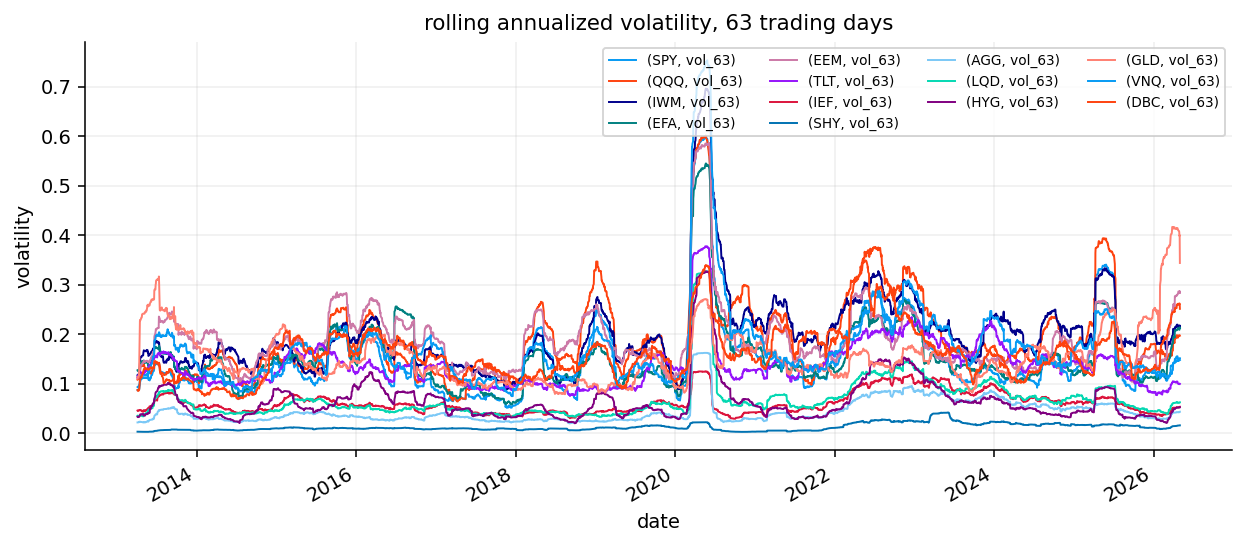

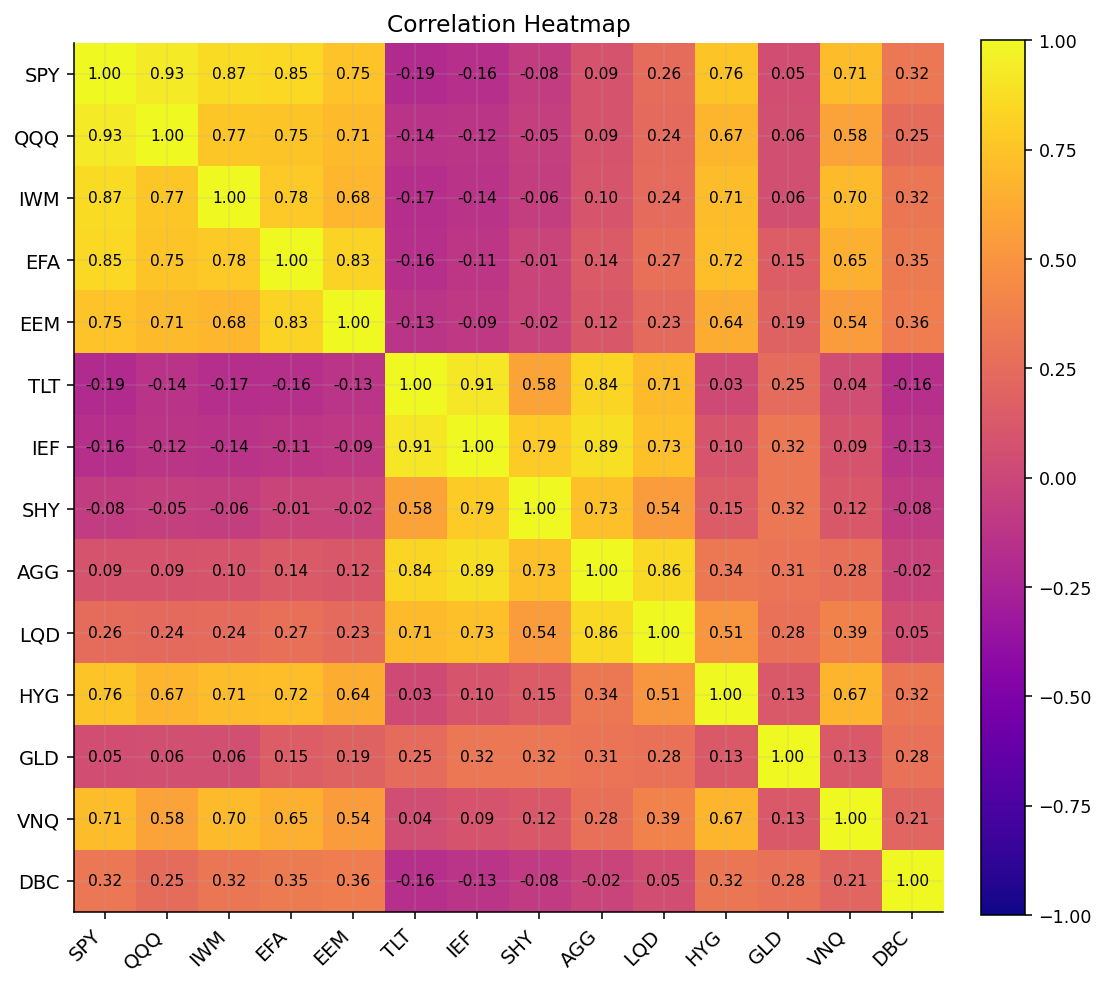

In [7]:
rolling_vol = rolling_volatility(returns, windows=(63,), annualization=annualization)
ax = rolling_vol.plot(figsize=(9, 4), lw=1.0)
ax.set_title("rolling annualized volatility, 63 trading days")
ax.set_ylabel("volatility")
ax.set_xlabel("date")
ax.legend(ncol=4, fontsize=7)
plt.tight_layout()
plt.show()

corr = corr_matrix(returns_p6)
fig, ax = plt.subplots(figsize=(8, 8))
ax = plot_corr_heatmap(ax, corr)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [8]:
fixed_benchmark_weights = {
    "SPY": 0.22, "QQQ": 0.08, "IWM": 0.04, "EFA": 0.09, "EEM": 0.05,
    "TLT": 0.08, "IEF": 0.08, "SHY": 0.05, "AGG": 0.10, "LQD": 0.05,
    "HYG": 0.04, "GLD": 0.05, "VNQ": 0.04, "DBC": 0.02}

asset_cap_map = {
    "SPY": 0.35, "QQQ": 0.25, "IWM": 0.15, "EFA": 0.20, "EEM": 0.15,
    "TLT": 0.25, "IEF": 0.25, "SHY": 0.20, "AGG": 0.25,
    "LQD": 0.15, "HYG": 0.08, "GLD": 0.10, "VNQ": 0.08, "DBC": 0.05}

asset_caps = pd.Series({asset: asset_cap_map.get(asset, w_max) for asset in assets}, index=assets, dtype=float)

sleeve_constraints = {
    "equity": {"assets": ["SPY", "QQQ", "IWM", "EFA", "EEM"], "min": 0.35, "max": 0.75},
    "bonds": {"assets": ["TLT", "IEF", "SHY", "AGG"], "min": 0.15, "max": 0.55},
    "credit": {"assets": ["LQD", "HYG"], "min": 0.00, "max": 0.18},
    "real_assets": {"assets": ["GLD", "VNQ", "DBC"], "min": 0.00, "max": 0.22}}

def normalize_box_weights(raw_weights, index, lower=0.0, upper=0.25):
    w = pd.Series(raw_weights, index=index, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    upper_s = pd.Series(upper, index=index, dtype=float) if np.isscalar(upper) else pd.Series(upper, index=index, dtype=float).reindex(index).fillna(w_max)
    w = w.clip(lower=max(lower, 0.0), upper=upper_s)
    if w.sum() <= 0:
        w = pd.Series(1.0 / len(index), index=index).clip(upper=upper_s)
    else:
        w = w / w.sum()
    if upper_s.sum() < 1.0 - 1e-10:
        return pd.Series(1.0 / len(index), index=index)
    for _ in range(100):
        over = w > upper_s + 1e-12
        if not over.any():
            break
        excess = float((w[over] - upper_s[over]).sum())
        w[over] = upper_s[over]
        room = (upper_s[~over] - w[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        w.loc[room.index] = w.loc[room.index] + excess * room / room.sum()
    w = w.clip(lower=lower, upper=upper_s)
    w = w / w.sum() if w.sum() > 0 else pd.Series(1.0 / len(index), index=index)
    return w

benchmark_raw = {ticker: fixed_benchmark_weights.get(ticker, 0.0) for ticker in assets}
benchmark_w = normalize_box_weights(benchmark_raw, assets, lower=w_min, upper=asset_caps)
if (benchmark_w > asset_caps + 1e-6).any() or abs(benchmark_w.sum() - 1.0) > 1e-6:
    benchmark_w = normalize_box_weights(pd.Series(1.0, index=assets), assets, lower=w_min, upper=asset_caps)
benchmark_table = pd.DataFrame({"asset": benchmark_w.index, "sleeve": [sleeve_map.get(ticker, "Other") for ticker in benchmark_w.index], "benchmark_weight": benchmark_w.values, "asset_cap": asset_caps.reindex(benchmark_w.index).values})
display(benchmark_table.round(4))


,asset,sleeve,benchmark_weight,asset_cap
0,SPY,US equity,0.2222,0.35
1,QQQ,US equity,0.0808,0.25
2,IWM,US equity,0.0404,0.15
3,EFA,International equity,0.0909,0.20
4,EEM,International equity,0.0505,0.15
5,TLT,Duration bonds,0.0808,0.25
6,IEF,Duration bonds,0.0808,0.25
7,SHY,Short bonds,0.0505,0.20
8,AGG,Core bonds,0.1010,0.25
9,LQD,Credit,0.0505,0.15


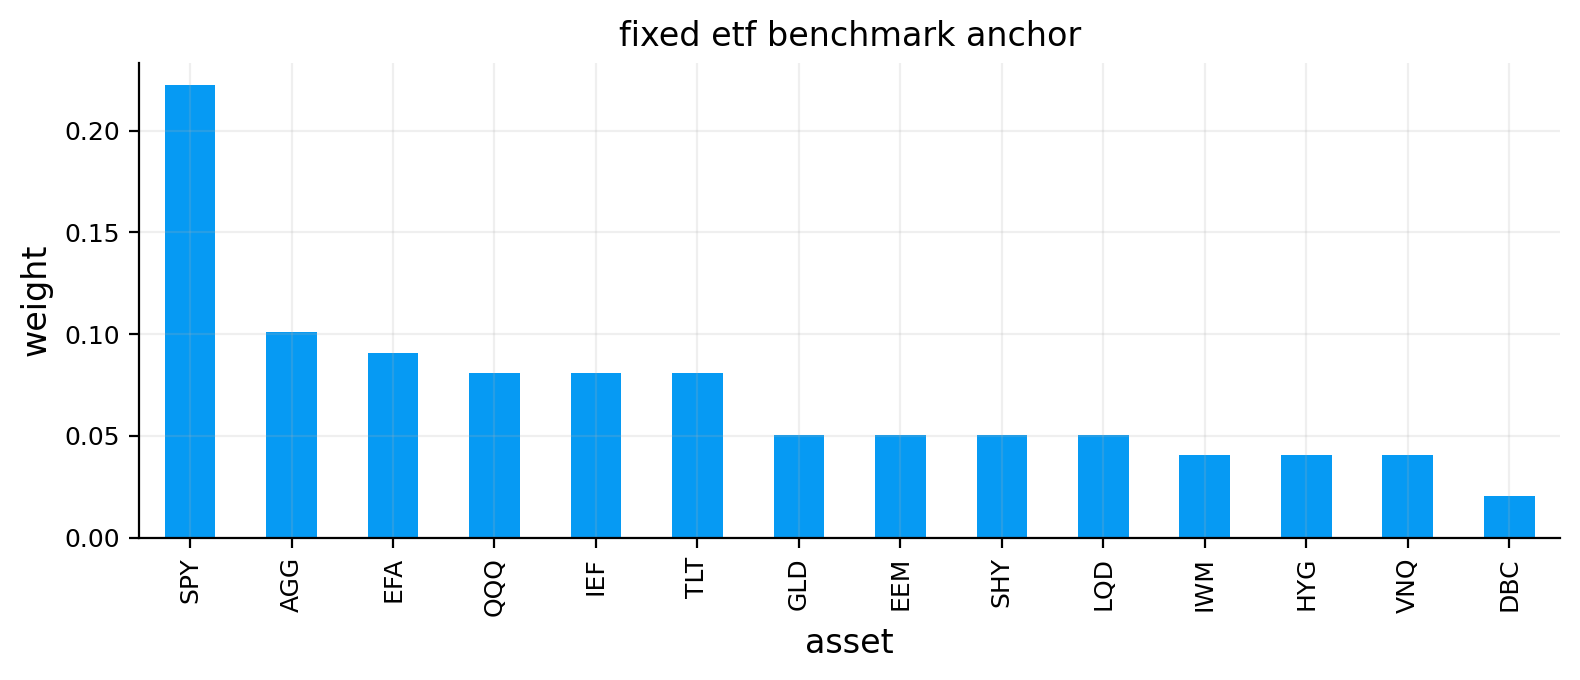

,sleeve,benchmark_weight
7,US equity,0.3434
3,Duration bonds,0.1616
4,International equity,0.1414
1,Core bonds,0.1010
5,Real assets,0.0909
2,Credit,0.0909
6,Short bonds,0.0505
0,Commodities,0.0202


In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5))
benchmark_w.sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("fixed etf benchmark anchor")
ax.set_ylabel("weight")
ax.set_xlabel("asset")
plt.tight_layout()
plt.show()
benchmark_sleeve = benchmark_table.groupby("sleeve", as_index=False)["benchmark_weight"].sum().sort_values("benchmark_weight", ascending=False)
display(benchmark_sleeve.round(4))


In [10]:
def local_make_psd(matrix, eps=1e-10):
    arr = np.asarray(matrix, dtype=float)
    arr = 0.5 * (arr + arr.T)
    vals, vecs = np.linalg.eigh(arr)
    vals = np.maximum(vals, eps)
    out = (vecs * vals) @ vecs.T
    return 0.5 * (out + out.T)

def make_psd_df(matrix, index):
    arr = make_psd(np.asarray(matrix, dtype=float), eps=1e-10)
    return pd.DataFrame(arr, index=index, columns=index)

def estimate_ewma_cov_at_date(returns, date, lookback=cov_lookback, lam=ewma_lambda):
    date = pd.Timestamp(date)
    pos = returns.index.searchsorted(date, side="right") - 1
    window = returns.iloc[max(0, pos - lookback + 1):pos + 1].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    cov_ann = estimate_covariance(window, method="EWMA", annualization=annualization, ewma_lambda=lam, return_df=True)
    return cov_ann


def estimate_delta_at_date(returns, date, benchmark_w, lookback=cov_lookback):
    date = pd.Timestamp(date)
    pos = returns.index.searchsorted(date, side="right") - 1
    window = returns.iloc[max(0, pos - lookback + 1):pos + 1][benchmark_w.index].fillna(0.0)
    bench_ret = window @ benchmark_w
    ann_return = float(bench_ret.mean() * annualization)
    ann_var = float(bench_ret.var(ddof=1) * annualization)
    raw_delta = delta_fallback if (not np.isfinite(ann_var) or ann_var <= 1e-10) else (ann_return - risk_free_daily * annualization) / ann_var
    if not np.isfinite(raw_delta):
        raw_delta = delta_fallback
    return float(np.clip(raw_delta, delta_min, delta_max))

cov_by_date = {}
delta_by_date = {}
prior_mu_by_date = {}
for dt in rebalance_dates:
    cov_ann = estimate_ewma_cov_at_date(returns, dt)
    delta_t = estimate_delta_at_date(returns, dt, benchmark_w)
    prior_mu = pd.Series(delta_t * cov_ann.loc[assets, assets].values @ benchmark_w.loc[assets].values, index=assets)
    cov_by_date[pd.Timestamp(dt)] = cov_ann
    delta_by_date[pd.Timestamp(dt)] = delta_t
    prior_mu_by_date[pd.Timestamp(dt)] = prior_mu
print("stored covariance and prior for", len(prior_mu_by_date), "rebalance dates")


stored covariance and prior for 125 rebalance dates


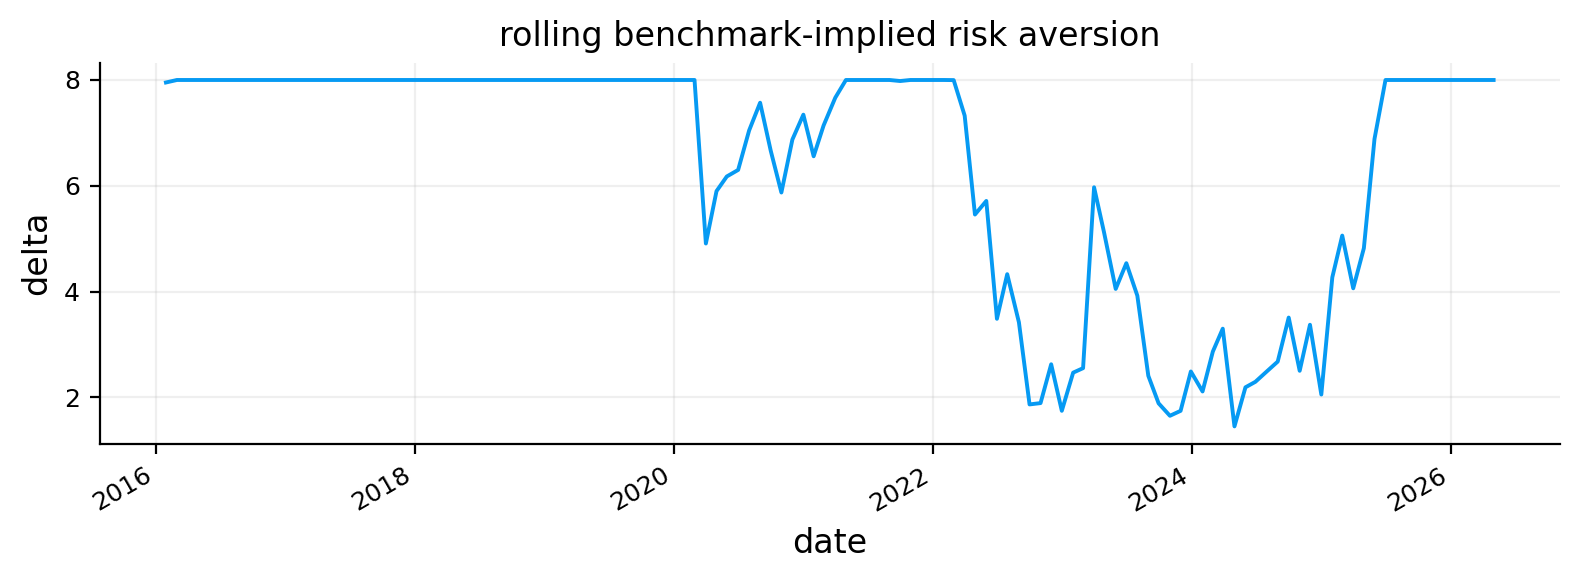

,asset,prior_mu,benchmark_weight
0,EEM,0.2038,0.0505
1,EFA,0.1552,0.0909
2,GLD,0.1525,0.0505
3,IWM,0.1483,0.0404
4,QQQ,0.1370,0.0808
5,SPY,0.1109,0.2222
6,VNQ,0.0769,0.0404
7,TLT,0.0385,0.0808
8,HYG,0.0361,0.0404
9,LQD,0.0350,0.0505


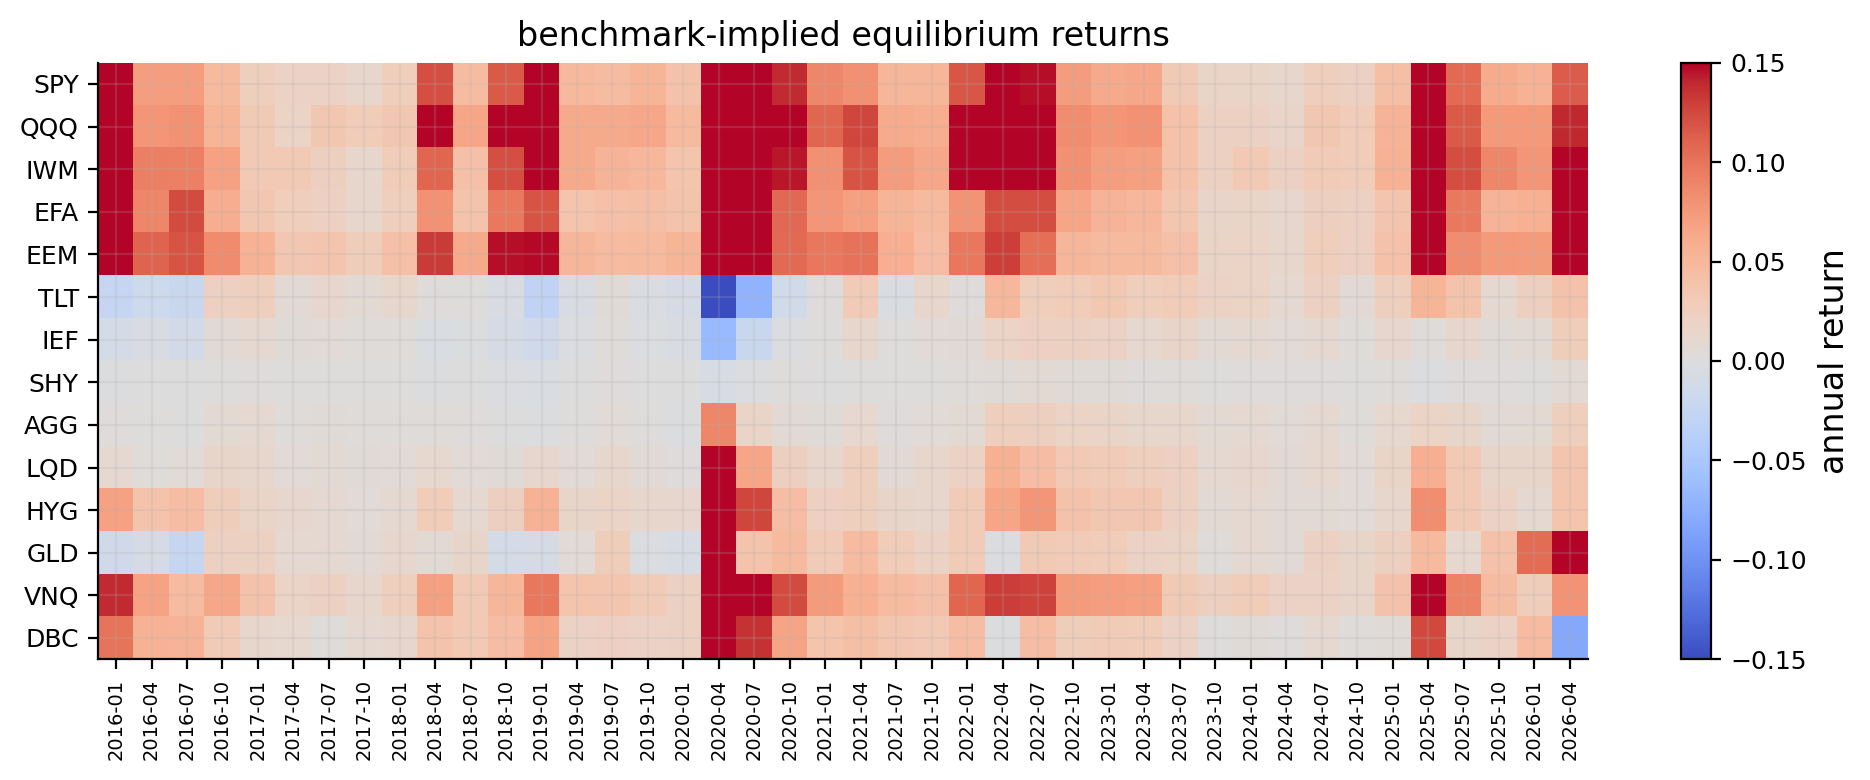

In [11]:
delta_series = pd.Series(delta_by_date).sort_index()
ax = delta_series.plot(figsize=(8, 3), lw=1.4)
ax.set_title("rolling benchmark-implied risk aversion")
ax.set_ylabel("delta")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

latest_rebalance_date = rebalance_dates[-1]
latest_prior = prior_mu_by_date[pd.Timestamp(latest_rebalance_date)].sort_values(ascending=False)
prior_table = pd.DataFrame({"asset": latest_prior.index, "prior_mu": latest_prior.values, "benchmark_weight": benchmark_w.reindex(latest_prior.index).values})
display(prior_table.round(4))

prior_mu_frame = pd.DataFrame(prior_mu_by_date).T.sort_index()
prior_mu_heat = prior_mu_frame.iloc[::max(1, len(prior_mu_frame) // 36)].T
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(prior_mu_heat, aspect="auto", cmap="coolwarm", vmin=-0.15, vmax=0.15)
ax.set_title("benchmark-implied equilibrium returns")
ax.set_yticks(range(len(prior_mu_heat.index)), prior_mu_heat.index)
ax.set_xticks(range(len(prior_mu_heat.columns)), [d.strftime("%Y-%m") for d in prior_mu_heat.columns], rotation=90, fontsize=7)
fig.colorbar(im, ax=ax, label="annual return")
plt.tight_layout()
plt.show()


In [12]:
def simple_nav(returns):
    returns = pd.Series(returns).dropna()
    return (1.0 + returns).cumprod()

def simple_drawdown(nav):
    nav = pd.Series(nav).dropna()
    return nav / nav.cummax() - 1.0

def equal_weight_vector(index):
    out = equal_weight(list(index), w_min=w_min, w_max=w_max, long_only=True, as_series=True)
    return out.reindex(index).fillna(0.0).to_numpy(dtype=float)

def clean_weight_array(weights, index, previous=None):
    if weights is None:
        weights = previous if previous is not None else equal_weight_vector(index)
    w = np.asarray(weights, dtype=float).reshape(-1)
    if len(w) != len(index) or not np.all(np.isfinite(w)):
        w = equal_weight_vector(index) if previous is None else np.asarray(previous, dtype=float)
    w = np.maximum(w, w_min)
    w = np.minimum(w, w_max)
    w = w / w.sum() if w.sum() > 1e-12 else equal_weight_vector(index)
    for _ in range(10):
        over = w > w_max
        if not over.any():
            break
        extra = (w[over] - w_max).sum()
        w[over] = w_max
        room = np.maximum(w_max - w[~over], 0.0)
        if room.sum() <= 1e-12:
            break
        w[~over] += extra * room / room.sum()
    w = np.maximum(w, w_min)
    w = np.minimum(w, w_max)
    return w / w.sum()

def momentum_mu_at_date(returns, date, mode="6-1", cov_ann=None):
    pos = returns.index.searchsorted(pd.Timestamp(date), side="right") - 1
    window = returns.iloc[max(0, pos - mu_lookback + 1):pos + 1].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    mu = momentum_mu(window, cov_ann=cov_ann, mode=mode, target_sharpe_ann=0.8, mu_cap_ann=0.30, annualization=annualization, return_series=True)
    return pd.Series(mu).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(-0.30, 0.30).reindex(assets).fillna(0.0)

def min_variance_weights(cov_ann, w_prev=None):
    w = minimum_variance(cov_ann=cov_ann, w_prev=w_prev, w_min=w_min, w_max=w_max, long_only=True, turnover_penalty_bps=cost_bps, raise_on_fail=False)
    return clean_weight_array(w, cov_ann.index, previous=w_prev), w is None
        

def mean_variance_weights(mu, cov_ann, w_prev=None, mv_lambda=bl_mv_lambda):
    w = mean_variance(mu_excess_ann=mu, cov_ann=cov_ann, w_prev=w_prev, mv_lambda=mv_lambda, w_min=w_min, w_max=w_max, long_only=True, turnover_penalty_bps=cost_bps, raise_on_fail=False)
    return clean_weight_array(w, cov_ann.index, previous=w_prev), w is None

def max_sharpe_fg_weights(mu, cov_ann, w_prev=None):
    w = max_sharpe_frontier_grid(mu_excess_ann=mu, cov_ann=cov_ann, w_prev=w_prev, grid_n=15, w_min=w_min, w_max=w_max, long_only=True, turnover_penalty_bps=cost_bps, raise_on_fail=False)
    return clean_weight_array(w, cov_ann.index, previous=w_prev), w is None


In [13]:
def backtest_result_to_dict(name, result, fallback_flags=None):
    flags = pd.Series(dtype=float) if fallback_flags is None else pd.Series(fallback_flags).sort_index()
    return {
        "returns": result.net_returns.rename(name),
        "gross_returns": result.gross_returns.rename(name),
        "nav": result.net_values.rename(name),
        "gross_nav": result.gross_values.rename(name),
        "weights": result.weights.copy(),
        "turnover": result.turnover.rename(name),
        "costs": result.costs.rename(name),
        "fallback_flags": flags.rename(name),
        "fallback_count": int(flags.sum()) if len(flags) else int(result.fallbacks),
    }

def make_weight_schedule(weight_func):
    rows = []
    fallback_rows = []
    w_prev = None
    for dt in rebalance_dates[:-1]:
        dt = pd.Timestamp(dt)
        w_new, fallback = weight_func(dt, w_prev)
        w_new = clean_weight_array(w_new, assets, previous=w_prev)
        rows.append(pd.Series(w_new, index=assets, name=dt))
        fallback_rows.append((dt, int(bool(fallback))))
        w_prev = w_new
    return pd.DataFrame(rows), pd.Series(dict(fallback_rows), dtype=float).sort_index()

def ew_weight_func(dt, w_prev):
    return equal_weight_vector(assets), False

def momentum_mv_weight_func(dt, w_prev):
    cov_ann = cov_by_date[pd.Timestamp(dt)].loc[assets, assets]
    mu = momentum_mu_at_date(returns_p6, dt, mode="12-1", cov_ann=cov_ann)
    return mean_variance_weights(mu, cov_ann, w_prev=w_prev, mv_lambda=bl_mv_lambda)

def maxsharpe_fg_mom_weight_func(dt, w_prev):
    cov_ann = cov_by_date[pd.Timestamp(dt)].loc[assets, assets]
    mu = momentum_mu_at_date(returns_p6, dt, mode="12-1", cov_ann=cov_ann)
    return max_sharpe_fg_weights(mu, cov_ann, w_prev=w_prev)

baseline_weight_schedules = {}
baseline_fallback_flags = {}
baseline_weight_schedules["Strategic Benchmark"] = pd.DataFrame([benchmark_w.reindex(assets).rename(pd.Timestamp(dt)) for dt in rebalance_dates[:-1]])
baseline_fallback_flags["Strategic Benchmark"] = pd.Series(0.0, index=pd.DatetimeIndex(rebalance_dates[:-1]))
baseline_weight_schedules["Equal Weight"], baseline_fallback_flags["Equal Weight"] = make_weight_schedule(ew_weight_func)
baseline_weight_schedules["EWMA Momentum MV"], baseline_fallback_flags["EWMA Momentum MV"] = make_weight_schedule(momentum_mv_weight_func)
baseline_weight_schedules["MaxSharpe_FG_EWMA_Mom"], baseline_fallback_flags["MaxSharpe_FG_EWMA_Mom"] = make_weight_schedule(maxsharpe_fg_mom_weight_func)

baseline_backtests = run_many_weights_backtests(
    baseline_weight_schedules,
    returns=returns_p6[assets],
    cost_bps=cost_bps,
    w_min=w_min,
    w_max=None,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)
baseline_candidates = {name: backtest_result_to_dict(name, result, baseline_fallback_flags[name]) for name, result in baseline_backtests.items()}
print("fixed baseline strategies:", list(baseline_candidates))


fixed baseline strategies: ['Strategic Benchmark', 'Equal Weight', 'EWMA Momentum MV', 'MaxSharpe_FG_EWMA_Mom']


In [14]:
def quick_metrics(ret, nav=None):
    ret = pd.Series(ret).dropna()
    nav = simple_nav(ret) if nav is None else pd.Series(nav).dropna()
    if ret.empty or nav.empty:
        return {"cagr": np.nan, "ann_vol": np.nan, "sharpe": np.nan, "max_drawdown": np.nan}
    years = max(len(nav) / annualization, 1e-9)
    cagr = float(nav.iloc[-1] ** (1.0 / years) - 1.0)
    ann_vol = float(ret.std(ddof=1) * math.sqrt(annualization))
    sharpe = float((ret.mean() - risk_free_daily) / ret.std(ddof=1) * math.sqrt(annualization)) if ret.std(ddof=1) > 1e-12 else np.nan
    return {"cagr": cagr, "ann_vol": ann_vol, "sharpe": sharpe, "max_drawdown": max_drawdown_from_nav(nav)}

candidate_rows = []
for name, result in baseline_candidates.items():
    m = quick_metrics(result["returns"], result["nav"])
    candidate_rows.append({"strategy": name, "cagr": m["cagr"], "ann_vol": m["ann_vol"], "sharpe": m["sharpe"], "max_drawdown": m["max_drawdown"], "avg_turnover": result["turnover"].mean(), "fallback_count": result["fallback_count"]})
baseline_candidate_summary = pd.DataFrame(candidate_rows).sort_values("sharpe", ascending=False)
display(baseline_candidate_summary.round(4))
baseline_results = {name: baseline_candidates[name] for name in ["Strategic Benchmark", "Equal Weight", "EWMA Momentum MV", "MaxSharpe_FG_EWMA_Mom"]}
print("using one fixed baseline parameter set; no in-sample hyperparameter search")


,strategy,cagr,ann_vol,sharpe,max_drawdown,avg_turnover,fallback_count
2,EWMA Momentum MV,0.0508,0.0552,0.9288,-0.1381,0.1352,0
0,Strategic Benchmark,0.0905,0.1011,0.9092,-0.2242,0.0144,0
1,Equal Weight,0.0828,0.0934,0.9017,-0.2039,0.0152,0
3,MaxSharpe_FG_EWMA_Mom,0.0808,0.1114,0.7553,-0.1655,0.1932,0


using one fixed baseline parameter set; no in-sample hyperparameter search


,avg_turnover
Strategic Benchmark,0.0144
Equal Weight,0.0152
EWMA Momentum MV,0.1352
MaxSharpe_FG_EWMA_Mom,0.1932


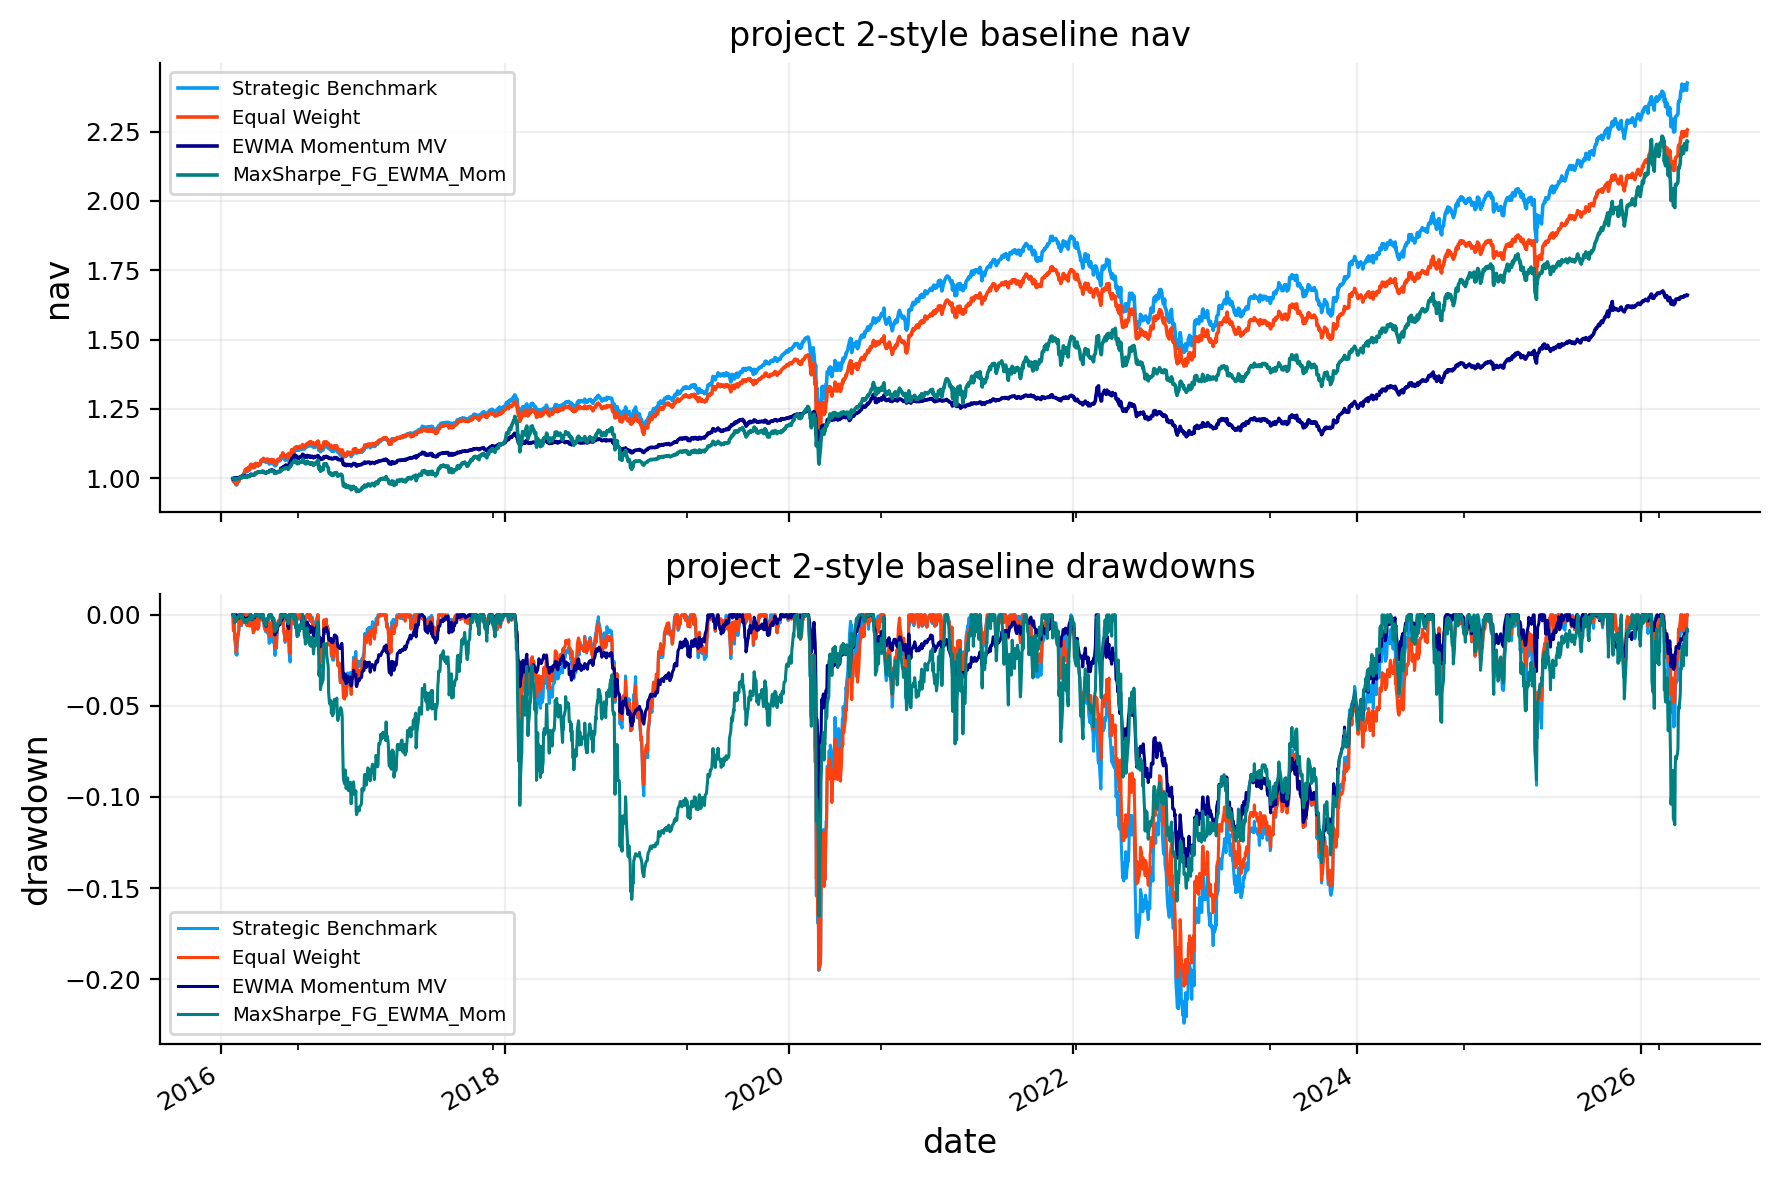

In [15]:
avg_turnover_table = pd.DataFrame({name: result["turnover"].mean() for name, result in baseline_results.items()}, index=["avg_turnover"]).T
display(avg_turnover_table.round(4))
baseline_nav = pd.DataFrame({name: result["nav"] for name, result in baseline_results.items()})
baseline_dd = baseline_nav / baseline_nav.cummax() - 1.0
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
baseline_nav.plot(ax=axes[0], lw=1.3)
axes[0].set_title("project 2-style baseline nav"); axes[0].set_ylabel("nav")
baseline_dd.plot(ax=axes[1], lw=1.1)
axes[1].set_title("project 2-style baseline drawdowns"); axes[1].set_ylabel("drawdown"); axes[1].set_xlabel("date")
plt.tight_layout(); plt.show()


In [16]:
risky_asset_names = ["SPY", "QQQ", "IWM", "EFA", "EEM", "HYG", "VNQ", "DBC"]
defensive_asset_names = ["TLT", "IEF", "SHY", "AGG", "LQD", "GLD"]

def winsorized_zscore(series):
    s = pd.Series(series, dtype=float).replace([np.inf, -np.inf], np.nan)
    good = s.dropna()
    if good.empty:
        return pd.Series(0.0, index=s.index)
    clipped = s.clip(good.quantile(0.05), good.quantile(0.95))
    std = clipped.std(ddof=0)
    if not np.isfinite(std) or std < 1e-12:
        return pd.Series(0.0, index=s.index)
    return ((clipped - clipped.mean()) / std).fillna(0.0)

def cumulative_return(window):
    if window is None or len(window) == 0:
        return np.nan
    return float((1.0 + window.dropna()).prod() - 1.0)

def compute_asset_signals(close, returns, date):
    date = pd.Timestamp(date)
    close_pos = close.index.searchsorted(date, side="right") - 1
    ret_pos = returns.index.searchsorted(date, side="right") - 1
    close_hist = close.iloc[:close_pos + 1]
    ret_hist = returns.iloc[:ret_pos + 1]
    rows = []
    for ticker in returns.columns:
        px = close_hist[ticker].dropna() if ticker in close_hist else pd.Series(dtype=float)
        rt = ret_hist[ticker].dropna() if ticker in ret_hist else pd.Series(dtype=float)
        if len(px) < 200 or len(rt) < 63:
            continue
        mom_3_0 = cumulative_return(rt.tail(63))
        mom_6_1 = cumulative_return(rt.iloc[-147:-21]) if len(rt) >= 147 else np.nan
        mom_12_1 = cumulative_return(rt.iloc[-273:-21]) if len(rt) >= 273 else np.nan
        trend_200 = float(px.iloc[-1] / px.tail(200).mean() - 1.0) if px.tail(200).mean() > 0 else np.nan
        vol_63 = float(rt.tail(63).std(ddof=1) * math.sqrt(annualization))
        high_252 = px.tail(252).max()
        dd_252 = float(px.iloc[-1] / high_252 - 1.0) if high_252 > 0 else np.nan
        rows.append({"ticker": ticker, "sleeve": sleeve_map.get(ticker, "Other"), "mom_3_0": mom_3_0, "mom_6_1": mom_6_1, "mom_12_1": mom_12_1, "trend_200": trend_200, "vol_63": vol_63, "dd_252": dd_252, "drawdown_quality": dd_252})
    asset_signal_table = pd.DataFrame(rows).set_index("ticker") if rows else pd.DataFrame()
    if asset_signal_table.empty:
        return asset_signal_table, {}
    asset_signal_table["score"] = (0.30 * winsorized_zscore(asset_signal_table["mom_6_1"]) + 0.20 * winsorized_zscore(asset_signal_table["mom_12_1"]) + 0.20 * winsorized_zscore(asset_signal_table["trend_200"]) - 0.20 * winsorized_zscore(asset_signal_table["vol_63"]) + 0.10 * winsorized_zscore(asset_signal_table["drawdown_quality"]))
    scores = asset_signal_table["score"]
    risky_available = [ticker for ticker in risky_asset_names if ticker in scores.index]
    defensive_available = [ticker for ticker in defensive_asset_names if ticker in scores.index]
    risky_median_score = float(scores.reindex(risky_available).median()) if risky_available else np.nan
    defensive_median_score = float(scores.reindex(defensive_available).median()) if defensive_available else np.nan
    risky_trend_breadth = float((asset_signal_table.reindex(risky_available)["trend_200"] > 0).mean()) if risky_available else np.nan
    spy_drawdown_252 = float(asset_signal_table.loc["SPY", "dd_252"]) if "SPY" in asset_signal_table.index else np.nan
    spy_vol_63 = float(asset_signal_table.loc["SPY", "vol_63"]) if "SPY" in asset_signal_table.index else np.nan
    if "SPY" in ret_hist.columns:
        spy_vol_line = ret_hist["SPY"].rolling(63).std() * math.sqrt(annualization)
        spy_vol_threshold = spy_vol_line.dropna().tail(252).quantile(0.80)
    else:
        spy_vol_threshold = np.nan
    equity_stress = bool((np.isfinite(spy_drawdown_252) and spy_drawdown_252 < -0.10) or (np.isfinite(spy_vol_63) and np.isfinite(spy_vol_threshold) and spy_vol_63 > spy_vol_threshold))
    credit_spread_signal = np.nan
    if "HYG" in ret_hist.columns and "LQD" in ret_hist.columns and len(ret_hist) >= 63:
        credit_spread_signal = cumulative_return(ret_hist["HYG"].tail(63)) - cumulative_return(ret_hist["LQD"].tail(63))
    market_state = {"risky_median_score": risky_median_score, "defensive_median_score": defensive_median_score, "risk_on_score": risky_median_score - defensive_median_score if np.isfinite(risky_median_score) and np.isfinite(defensive_median_score) else np.nan, "risky_trend_breadth": risky_trend_breadth, "spy_drawdown_252": spy_drawdown_252, "spy_vol_63": spy_vol_63, "equity_stress": equity_stress, "credit_spread_signal": credit_spread_signal, "dollar_trend": float(asset_signal_table.loc["UUP", "trend_200"]) if "UUP" in asset_signal_table.index else np.nan, "real_asset_score": float(scores.reindex([x for x in ["GLD", "DBC"] if x in scores.index]).median()) if any(x in scores.index for x in ["GLD", "DBC"]) else np.nan, "bond_score": float(scores.reindex([x for x in ["TLT", "IEF", "AGG"] if x in scores.index]).median()) if any(x in scores.index for x in ["TLT", "IEF", "AGG"]) else np.nan}
    return asset_signal_table.sort_values("score", ascending=False), market_state


In [17]:
latest_signal_table, latest_market_state = compute_asset_signals(signal_close, signal_returns, latest_rebalance_date)
signal_display_cols = ["sleeve", "mom_6_1", "mom_12_1", "trend_200", "vol_63", "dd_252", "score"]
display(latest_signal_table[signal_display_cols].reset_index().round(4))
print("the score ranks assets for relative views; it is not used as a standalone return forecast")
print(latest_market_state)


,ticker,sleeve,mom_6_1,mom_12_1,trend_200,vol_63,dd_252,score
0,DBC,Commodities,0.3158,0.3176,0.2975,0.2512,-0.0093,1.2478
1,EEM,International equity,0.0871,0.3412,0.1634,0.2832,0.0000,0.5100
2,GLD,Real assets,0.2317,0.5195,0.0808,0.3438,-0.1466,0.4467
3,IWM,US equity,0.0367,0.2645,0.1299,0.2157,0.0000,0.2555
4,QQQ,US equity,-0.0243,0.2521,0.1182,0.1969,0.0000,0.0538
5,EFA,International equity,0.0753,0.2497,0.0708,0.2131,-0.0337,0.0314
6,SPY,US equity,-0.0108,0.1848,0.0789,0.1514,0.0000,-0.0551
7,HYG,Credit,0.0112,0.0715,0.0200,0.0524,-0.0021,-0.1202
8,SHY,Short bonds,0.0134,0.0361,0.0092,0.0158,-0.0026,-0.1632
9,UUP,Dollar,0.0424,0.0048,0.0138,0.0626,-0.0204,-0.2354


the score ranks assets for relative views; it is not used as a standalone return forecast
{'risky_median_score': 0.04259310891654496, 'defensive_median_score': -0.2920673841160041, 'risk_on_score': 0.334660493032549, 'risky_trend_breadth': 1.0, 'spy_drawdown_252': 0.0, 'spy_vol_63': 0.15136413478464925, 'equity_stress': False, 'credit_spread_signal': 0.009586676538705818, 'dollar_trend': 0.013843082442195564, 'real_asset_score': 0.8472567564813773, 'bond_score': -0.3499289259413922}


In [18]:
def make_view_row(view_family, view_name, economic_label, long_assets, short_assets, signal_value, risk_orientation, source="interpretable", priority=1.0):
    long_assets = list(dict.fromkeys([x for x in long_assets if x in assets]))
    short_assets = list(dict.fromkeys([x for x in short_assets if x in assets]))
    if not long_assets or not short_assets or not np.isfinite(signal_value):
        return None
    signal_value = float(signal_value)
    cap = family_q_caps.get(view_family, view_tilt_max)
    q_hint = float(cap * math.tanh(0.75 * abs(signal_value)))
    return {
        "view_family": view_family,
        "view_name": view_name,
        "economic_label": economic_label,
        "long_assets": long_assets,
        "short_assets": short_assets,
        "signal_value": signal_value,
        "q_tilt": q_hint,
        "q": q_hint,
        "risk_orientation": risk_orientation,
        "source": source,
        "priority": float(priority),
    }

def available(signal_table, names):
    return [x for x in names if x in signal_table.index]

def metric(signal_table, asset, col, default=np.nan):
    if asset not in signal_table.index or col not in signal_table.columns:
        return default
    val = signal_table.loc[asset, col]
    return float(val) if np.isfinite(val) else default

def score_value(signal_table, asset):
    return metric(signal_table, asset, "score")

def median_score(signal_table, names):
    names = available(signal_table, names)
    if not names:
        return np.nan
    return float(signal_table.reindex(names)["score"].median())

def best_assets(signal_table, candidates, n=1):
    names = available(signal_table, candidates)
    if not names:
        return []
    return list(signal_table.reindex(names).sort_values("score", ascending=False).head(n).index)

def worst_assets(signal_table, candidates, n=1):
    names = available(signal_table, candidates)
    if not names:
        return []
    return list(signal_table.reindex(names).sort_values("score", ascending=True).head(n).index)

def make_simple_interpretable_views(signal_table, market_state):
    rows = []
    if signal_table.empty:
        return rows
    equity_stress = bool(market_state.get("equity_stress", False))
    breadth = market_state.get("risky_trend_breadth", np.nan)
    credit_signal = market_state.get("credit_spread_signal", np.nan)

    if all(x in signal_table.index for x in ["SPY", "QQQ", "TLT", "IEF"]):
        equity_score = median_score(signal_table, ["SPY", "QQQ"])
        duration_score = median_score(signal_table, ["TLT", "IEF"])
        spread = equity_score - duration_score
        if metric(signal_table, "SPY", "trend_200") > 0 and np.isfinite(breadth) and breadth >= 0.50 and np.isfinite(credit_signal) and credit_signal > -0.02 and spread > view_entry_z:
            row = make_view_row("equity_duration_risk_on", "equity leaders over duration", "equity risk-on leadership versus duration", best_assets(signal_table, ["SPY", "QQQ"], n=1), worst_assets(signal_table, ["TLT", "IEF"], n=1), spread, "risk_on", priority=3.0)
            if row is not None:
                rows.append(row)

    if all(x in signal_table.index for x in ["QQQ", "SPY"]):
        spread = score_value(signal_table, "QQQ") - score_value(signal_table, "SPY")
        if metric(signal_table, "QQQ", "trend_200") > 0 and metric(signal_table, "SPY", "trend_200") > 0 and not equity_stress and spread > view_entry_z + 0.10 and metric(signal_table, "QQQ", "mom_6_1") > metric(signal_table, "SPY", "mom_6_1"):
            row = make_view_row("growth_leadership", "QQQ over SPY", "growth leadership versus broad US equity", ["QQQ"], ["SPY"], spread, "risk_on", priority=2.2)
            if row is not None:
                rows.append(row)

    quality = available(signal_table, ["SPY", "QQQ"])
    cyclicals = available(signal_table, ["IWM", "EEM", "VNQ", "HYG"])
    if quality and cyclicals:
        spread = median_score(signal_table, quality) - median_score(signal_table, cyclicals)
        if not equity_stress and metric(signal_table, "SPY", "trend_200") > 0 and np.isfinite(breadth) and breadth >= 0.50 and spread > view_entry_z:
            row = make_view_row("large_quality_vs_cyclicals", "large liquid equity over cyclicals", "large liquid equity versus cyclical risk assets", best_assets(signal_table, quality, n=min(2, len(quality))), worst_assets(signal_table, cyclicals, n=min(2, len(cyclicals))), spread, "risk_on", priority=2.5)
            if row is not None:
                rows.append(row)

    if all(x in signal_table.index for x in ["HYG", "LQD"]):
        spread = score_value(signal_table, "HYG") - score_value(signal_table, "LQD")
        if metric(signal_table, "HYG", "trend_200") > 0 and metric(signal_table, "HYG", "mom_6_1") > 0 and spread > view_entry_z + 0.20 and np.isfinite(credit_signal) and credit_signal > 0.02 and not equity_stress:
            row = make_view_row("credit_risk_confirmation", "HYG over LQD", "confirmed credit risk appetite", ["HYG"], ["LQD"], spread, "risk_on", priority=1.0)
            if row is not None:
                rows.append(row)
    return rows

latest_simple_views = make_simple_interpretable_views(latest_signal_table, latest_market_state)
latest_simple_table = pd.DataFrame(latest_simple_views)
if not latest_simple_table.empty:
    display(latest_simple_table[["view_family", "view_name", "economic_label", "long_assets", "short_assets", "signal_value", "q", "risk_orientation"]].round(4))
else:
    print("no simple interpretable views active on the latest rebalance date")


,view_family,view_name,economic_label,long_assets,short_assets,signal_value,q,risk_orientation
0,equity_duration_risk_on,equity leaders over duration,equity risk-on leadership versus duration,[QQQ],[TLT],0.5195,0.013,risk_on


In [19]:
view_theme_map = {
    "equity_duration_risk_on": "equity_duration",
    "growth_leadership": "growth_leadership",
    "large_quality_vs_cyclicals": "quality_vs_cyclicals",
    "short_duration_bond_defense": "short_duration",
    "duration_recovery": "duration_recovery",
    "inflation_vs_duration": "inflation_duration",
    "credit_risk_confirmation": "credit_confirmation",
}

def view_theme(row):
    return view_theme_map.get(row.get("view_family"), row.get("view_family", "other"))

def make_systematic_signal_table(signal_table, market_state):
    if signal_table.empty:
        return pd.DataFrame()
    rows = []
    rows.append({"signal": "breadth", "value": market_state.get("risky_trend_breadth", np.nan)})
    if all(x in signal_table.index for x in ["SPY", "QQQ", "TLT", "IEF"]):
        rows.append({"signal": "equity_minus_duration", "value": median_score(signal_table, ["SPY", "QQQ"]) - median_score(signal_table, ["TLT", "IEF"])})
    if all(x in signal_table.index for x in ["SHY", "TLT", "IEF", "AGG"]):
        rows.append({"signal": "short_duration_minus_bonds", "value": score_value(signal_table, "SHY") - median_score(signal_table, ["TLT", "IEF", "AGG"])})
    if all(x in signal_table.index for x in ["DBC", "TLT", "IEF"]):
        rows.append({"signal": "inflation_minus_duration", "value": score_value(signal_table, "DBC") - median_score(signal_table, ["TLT", "IEF"])})
    return pd.DataFrame(rows)

def view_signature(row):
    return (tuple(sorted(row.get("long_assets", []))), tuple(sorted(row.get("short_assets", []))))

def make_systematic_views(signal_table, market_state, simple_views, cross_section_active=False):
    rows = []
    if signal_table.empty:
        return rows
    simple_signatures = {view_signature(row) for row in simple_views}
    equity_stress = bool(market_state.get("equity_stress", False))
    credit_signal = market_state.get("credit_spread_signal", np.nan)

    if all(x in signal_table.index for x in ["SHY", "TLT", "IEF", "AGG"]):
        spread = score_value(signal_table, "SHY") - median_score(signal_table, ["TLT", "IEF", "AGG"])
        if metric(signal_table, "TLT", "trend_200") < 0 and metric(signal_table, "IEF", "trend_200") < 0 and metric(signal_table, "TLT", "mom_6_1") < 0 and metric(signal_table, "IEF", "mom_6_1") < 0 and spread > view_entry_z * 0.75:
            row = make_view_row("short_duration_bond_defense", "SHY over weak duration bonds", "short-duration bond defense versus duration", ["SHY"], worst_assets(signal_table, ["TLT", "IEF", "AGG"], n=2), spread, "risk_off", source="systematic", priority=2.2)
            if row is not None and view_signature(row) not in simple_signatures:
                rows.append(row)

    if all(x in signal_table.index for x in ["SHY", "TLT", "IEF"]):
        duration_score = median_score(signal_table, ["TLT", "IEF"])
        spread = duration_score - score_value(signal_table, "SHY")
        if spread > view_entry_z and (metric(signal_table, "TLT", "trend_200") > 0 or metric(signal_table, "IEF", "trend_200") > 0) and ((np.isfinite(credit_signal) and credit_signal < 0) or equity_stress):
            row = make_view_row("duration_recovery", "duration recovery over SHY", "duration recovery versus short bills", best_assets(signal_table, ["TLT", "IEF"], n=1), ["SHY"], spread, "risk_off", source="systematic", priority=2.0)
            if row is not None and view_signature(row) not in simple_signatures:
                rows.append(row)

    if all(x in signal_table.index for x in ["DBC", "TLT", "IEF"]):
        spread = score_value(signal_table, "DBC") - median_score(signal_table, ["TLT", "IEF"])
        if metric(signal_table, "DBC", "trend_200") > 0 and metric(signal_table, "DBC", "mom_6_1") > 0 and metric(signal_table, "DBC", "mom_12_1") > 0 and (metric(signal_table, "TLT", "trend_200") < 0 or metric(signal_table, "IEF", "trend_200") < 0) and spread > view_entry_z:
            long_side = ["DBC"]
            if "GLD" in signal_table.index and metric(signal_table, "GLD", "trend_200") > 0 and score_value(signal_table, "GLD") > 0:
                long_side.append("GLD")
            short_side = worst_assets(signal_table, ["TLT", "IEF", "AGG"], n=2)
            row = make_view_row("inflation_vs_duration", "inflation assets over duration", "commodity inflation pressure versus duration bonds", long_side, short_side, spread, "neutral", source="systematic", priority=2.0)
            if row is not None and view_signature(row) not in simple_signatures:
                rows.append(row)
    return rows

def combine_and_rank_views(simple_views, systematic_views):
    rows, seen = [], set()
    for row in simple_views + systematic_views:
        sig = view_signature(row)
        if sig in seen:
            continue
        seen.add(sig)
        row = dict(row)
        row["economic_theme"] = view_theme(row)
        row["view_strength"] = abs(row["signal_value"])
        row["adjusted_strength"] = row["view_strength"] + 0.05 * row.get("priority", 0.0)
        rows.append(row)
    return sorted(rows, key=lambda x: x["adjusted_strength"], reverse=True)[:max_active_views]

def family_reliability_stats(view_family, payoff_history, current_date):
    current_date = pd.Timestamp(current_date)
    if payoff_history is None or len(payoff_history) == 0:
        sample = pd.DataFrame()
    else:
        sample = payoff_history[(payoff_history["view_family"] == view_family) & (payoff_history["date"] < current_date) & (payoff_history["payoff_end_date"] < current_date)].sort_values("date")
    n_obs = int(len(sample))
    if n_obs == 0:
        return {"n_obs": 0, "hit_rate": np.nan, "recent_hit_rate": np.nan, "avg_payoff": 0.0, "payoff_vol": np.nan, "payoff_ir": 0.0, "t_stat": 0.0, "info_coefficient": 0.0, "sign_stability": np.nan, "recent_decay": 0.0, "sample_score": 0.0}
    payoff_col = "payoff_ann" if "payoff_ann" in sample.columns else "payoff"
    payoff = pd.to_numeric(sample[payoff_col], errors="coerce").dropna()
    n_obs = int(len(payoff))
    avg_payoff = float(payoff.mean()) if n_obs else 0.0
    payoff_vol = float(payoff.std(ddof=1)) if n_obs > 1 else np.nan
    payoff_ir = avg_payoff / payoff_vol if np.isfinite(payoff_vol) and payoff_vol > 1e-10 else 0.0
    t_stat = payoff_ir * math.sqrt(n_obs) if n_obs > 1 else 0.0
    hit_rate = float((payoff > 0).mean()) if n_obs else np.nan
    recent = payoff.tail(6)
    recent_hit_rate = float((recent > 0).mean()) if len(recent) else np.nan
    signal_strength = pd.to_numeric(sample.get("signal_strength", sample["signal_value"].abs()), errors="coerce").reindex(payoff.index).fillna(0.0)
    info_coefficient = float(signal_strength.corr(payoff)) if n_obs >= 8 and signal_strength.std(ddof=1) > 1e-10 and payoff.std(ddof=1) > 1e-10 else 0.0
    if not np.isfinite(info_coefficient):
        info_coefficient = 0.0
    recent_decay = float(recent.mean() - avg_payoff) if len(recent) else 0.0
    return {"n_obs": n_obs, "hit_rate": hit_rate, "recent_hit_rate": recent_hit_rate, "avg_payoff": avg_payoff, "payoff_vol": payoff_vol, "payoff_ir": payoff_ir, "t_stat": t_stat, "info_coefficient": info_coefficient, "sign_stability": hit_rate, "recent_decay": recent_decay, "sample_score": min(1.0, n_obs / 24.0)}

def learned_q_for_view(row, payoff_history, current_date, raw_q_tilt, tilt_cap):
    stats = family_reliability_stats(row["view_family"], payoff_history, current_date)
    n_obs = stats["n_obs"]
    signal_strength = float(abs(row.get("signal_value", 0.0)))
    raw_q_tilt = float(raw_q_tilt)
    if payoff_history is None or len(payoff_history) == 0 or n_obs < 8:
        q_est = (0.25 + 0.05 * min(n_obs, 7)) * raw_q_tilt
        return {**stats, "q_tilt_learned": float(np.clip(q_est, 0.0, tilt_cap)), "q_shrink": 0.0, "q_dropped": False, "q_model": "small-sample conservative tilt"}
    sample = payoff_history[(payoff_history["view_family"] == row["view_family"]) & (payoff_history["date"] < pd.Timestamp(current_date)) & (payoff_history["payoff_end_date"] < pd.Timestamp(current_date))].copy()
    payoff_col = "payoff_ann" if "payoff_ann" in sample.columns else "payoff"
    x = pd.to_numeric(sample.get("signal_strength", sample["signal_value"].abs()), errors="coerce").fillna(0.0).to_numpy(dtype=float)
    y = pd.to_numeric(sample[payoff_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    denom = float(np.dot(x, x))
    slope = float(np.dot(x, y) / denom) if denom > 1e-10 else 0.0
    predicted = slope * signal_strength
    sample_mean = float(np.mean(y)) if len(y) else 0.0
    shrink = n_obs / (n_obs + 12.0)
    learned_expected_payoff = shrink * (0.70 * predicted + 0.30 * sample_mean) + (1.0 - shrink) * (0.35 * raw_q_tilt)
    learned_expected_payoff = float(np.clip(learned_expected_payoff, -tilt_cap, tilt_cap))
    if learned_expected_payoff <= 0:
        return {**stats, "q_tilt_learned": 0.0, "q_shrink": shrink, "q_dropped": True, "q_model": "negative learned payoff"}
    return {**stats, "q_tilt_learned": learned_expected_payoff, "q_shrink": shrink, "q_dropped": False, "q_model": "family learned payoff"}

def confidence_from_stats(stats, row, market_state, confidence_mode):
    n_obs = stats["n_obs"]
    hit_rate = stats["hit_rate"] if np.isfinite(stats["hit_rate"]) else 0.50
    recent_hit_rate = stats["recent_hit_rate"] if np.isfinite(stats["recent_hit_rate"]) else hit_rate
    payoff_ir = stats["payoff_ir"] if np.isfinite(stats["payoff_ir"]) else 0.0
    t_stat = stats["t_stat"] if np.isfinite(stats["t_stat"]) else 0.0
    info_coefficient = stats["info_coefficient"] if np.isfinite(stats["info_coefficient"]) else 0.0
    sample_score = stats["sample_score"]
    confidence = 0.38
    confidence += 0.17 * math.tanh(t_stat / 2.0)
    confidence += 0.14 * math.tanh(2.0 * payoff_ir)
    confidence += 0.11 * math.tanh(2.0 * info_coefficient)
    confidence += 0.18 * (hit_rate - 0.50) * 2.0
    confidence += 0.05 * sample_score
    if n_obs < 8:
        confidence = min(confidence, 0.50)
    if payoff_ir <= 0 and hit_rate <= 0.52:
        confidence = min(confidence, 0.45)
    if recent_hit_rate < hit_rate - 0.15 or stats.get("recent_decay", 0.0) < -0.005:
        confidence -= 0.06
    if hit_rate < 0.45 or payoff_ir < -0.10:
        confidence = min(confidence, 0.35)
    if market_state.get("dollar_trend", 0.0) > 0.05 and row.get("risk_orientation") == "risk_on":
        confidence -= 0.02
    haircut_multiplier = 1.0
    if confidence_mode == "fixed":
        confidence = 0.50
    elif confidence_mode == "haircut":
        if market_state.get("equity_stress", False) and row.get("risk_orientation") == "risk_on":
            haircut_multiplier *= 0.85
        if recent_hit_rate < hit_rate - 0.15:
            haircut_multiplier *= 0.80
        confidence = float(np.clip(confidence * haircut_multiplier, haircut_conf_floor, haircut_conf_cap))
    else:
        confidence = float(np.clip(confidence, conf_floor, conf_cap))
    out = dict(stats)
    out.update({"confidence": confidence, "confidence_mode": confidence_mode, "haircut_multiplier": haircut_multiplier, "risk_orientation": row.get("risk_orientation", "neutral")})
    return out

def confidence_for_view(row, payoff_history, current_date, market_state, confidence_mode):
    stats = family_reliability_stats(row["view_family"], payoff_history, current_date)
    return confidence_from_stats(stats, row, market_state, confidence_mode)

def select_selected_views(active_views, payoff_history, current_date, market_state, confidence_mode):
    rows = []
    log_rows = []
    for row in active_views:
        row = dict(row)
        row["economic_theme"] = view_theme(row)
        details = confidence_for_view(row, payoff_history, current_date, market_state, confidence_mode)
        hit_rate = details["hit_rate"]
        recent_hit_rate = details["recent_hit_rate"]
        payoff_ir = details["payoff_ir"]
        n_obs = details["n_obs"]
        skip = False
        reason = "kept"
        if np.isfinite(hit_rate) and np.isfinite(payoff_ir) and hit_rate < 0.45 and payoff_ir < 0:
            skip = True; reason = "weak family evidence"
        if n_obs >= 8 and np.isfinite(recent_hit_rate) and recent_hit_rate < 0.30:
            skip = True; reason = "recent hit too low"
        selected_score = 0.45 * abs(row.get("signal_value", 0.0)) + 0.30 * details["confidence"] + 0.15 * max(payoff_ir, 0.0) + 0.10 * row.get("priority", 0.0)
        multiplier = float(np.clip((details["confidence"] - 0.35) / 0.35, 0.0, 1.0))
        log_rows.append({"date": pd.Timestamp(current_date), "view_family": row["view_family"], "view_name": row["view_name"], "economic_theme": row["economic_theme"], "kept": not skip, "scale_reason": reason, "confidence_mode": confidence_mode, "confidence": details["confidence"], "reliability_multiplier": multiplier, "selected_score": selected_score, "n_obs": n_obs, "hit_rate": hit_rate, "recent_hit_rate": recent_hit_rate, "payoff_ir": payoff_ir, "t_stat": details["t_stat"], "info_coefficient": details["info_coefficient"], "signal_value": row.get("signal_value", np.nan), "view_strength": abs(row.get("signal_value", 0.0)), "source": row.get("source", "")})
        if not skip:
            row.update({"confidence": details["confidence"], "hit_rate": hit_rate, "recent_hit_rate": recent_hit_rate, "payoff_ir": payoff_ir, "t_stat": details["t_stat"], "info_coefficient": details["info_coefficient"], "n_obs": n_obs, "reliability_multiplier": multiplier, "selected_score": selected_score})
            rows.append(row)
    if not rows:
        return [], log_rows
    theme_best = {}
    for row in rows:
        theme = row["economic_theme"]
        if theme not in theme_best or row["selected_score"] > theme_best[theme]["selected_score"]:
            theme_best[theme] = row
    selected = sorted(theme_best.values(), key=lambda x: x["selected_score"], reverse=True)[:max_active_selected_views]
    return selected, log_rows

latest_systematic_signals = make_systematic_signal_table(latest_signal_table, latest_market_state)
display(latest_systematic_signals.round(4))


,signal,value
0,breadth,1.0000
1,equity_minus_duration,0.5195
2,short_duration_minus_bonds,0.1867
3,inflation_minus_duration,1.7680


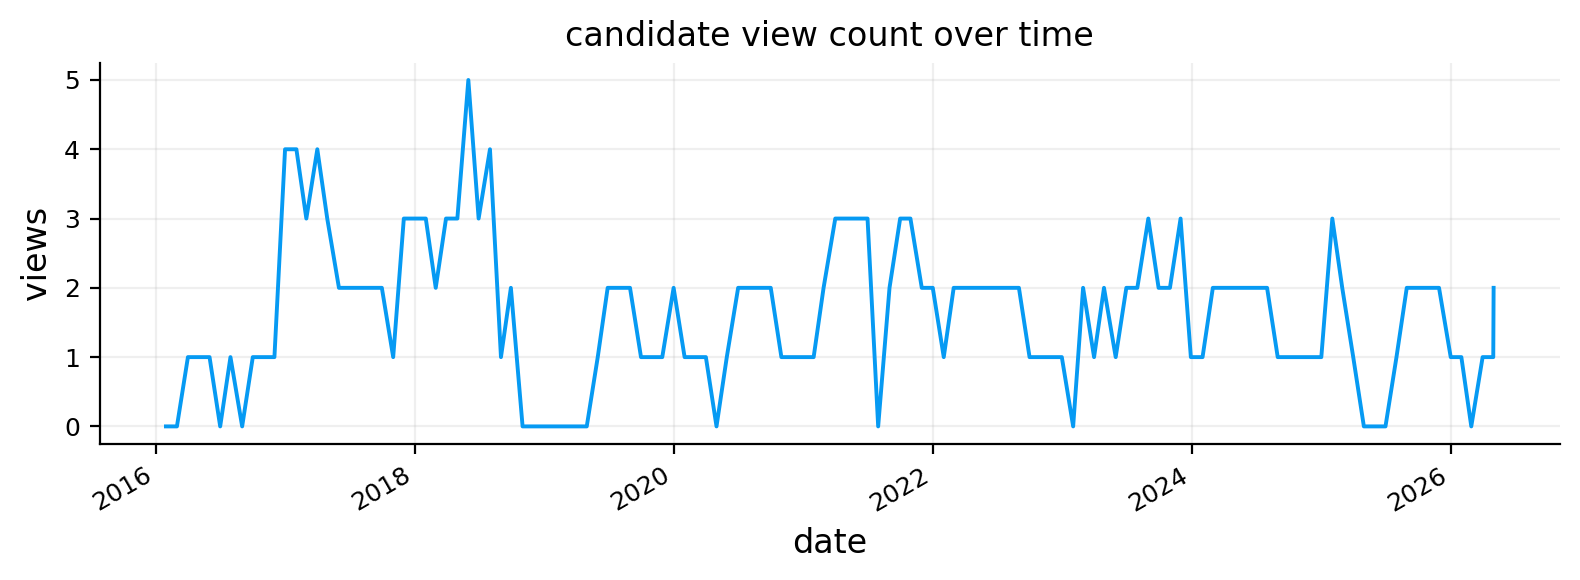

,view_family,view_name,economic_label,long_assets,short_assets,signal_value,q,risk_orientation,source
0,inflation_vs_duration,inflation assets over duration,commodity inflation pressure versus duration b...,"[DBC, GLD]","[TLT, IEF]",1.7680,0.0156,neutral,systematic
1,equity_duration_risk_on,equity leaders over duration,equity risk-on leadership versus duration,[QQQ],[TLT],0.5195,0.0130,risk_on,interpretable


,active_count,avg_abs_q,avg_signal_strength
view_family,,,
equity_duration_risk_on,70,0.0252,1.3097
large_quality_vs_cyclicals,51,0.0146,0.9388
inflation_vs_duration,33,0.0140,1.4703
short_duration_bond_defense,28,0.0089,0.6540
duration_recovery,12,0.0086,0.7079
growth_leadership,4,0.0164,1.0679
credit_risk_confirmation,3,0.0068,0.8562


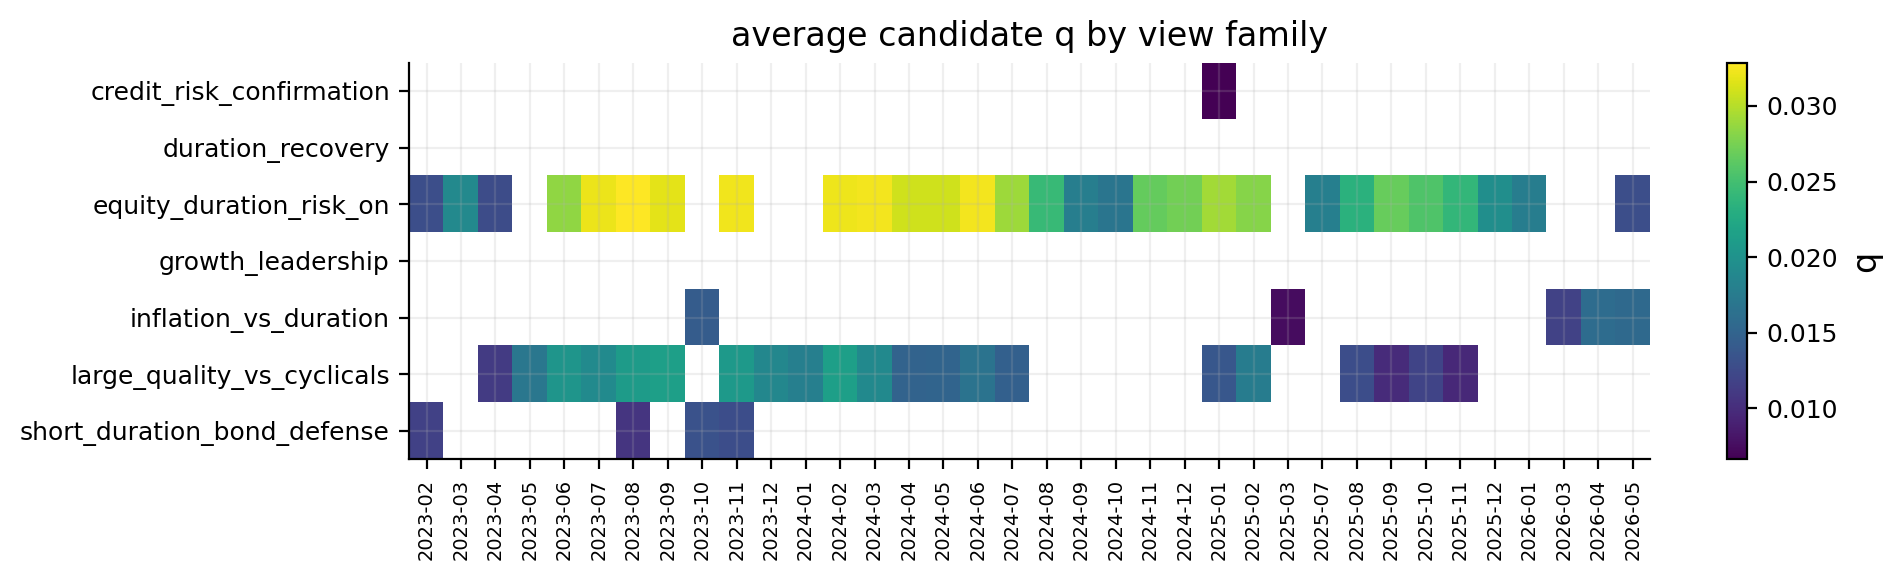

In [20]:
view_cache = {}
view_log_rows = []
for dt in rebalance_dates:
    signal_table, market_state = compute_asset_signals(signal_close, signal_returns, dt)
    simple_views = make_simple_interpretable_views(signal_table, market_state)
    systematic_signals = make_systematic_signal_table(signal_table, market_state)
    systematic_views = make_systematic_views(signal_table, market_state, simple_views)
    active_views = combine_and_rank_views(simple_views, systematic_views)
    view_cache[pd.Timestamp(dt)] = {
        "asset_signal_table": signal_table,
        "market_state": market_state,
        "simple_views": simple_views,
        "systematic_signals": systematic_signals,
        "systematic_views": systematic_views,
        "active_views": active_views,
    }
    for row in active_views:
        rec = dict(row)
        rec["date"] = pd.Timestamp(dt)
        view_log_rows.append(rec)
view_preview_log = pd.DataFrame(view_log_rows)
active_count_series = view_preview_log.groupby("date").size().reindex(rebalance_dates, fill_value=0) if not view_preview_log.empty else pd.Series(0, index=rebalance_dates)
ax = active_count_series.plot(figsize=(8, 3), lw=1.4)
ax.set_title("candidate view count over time")
ax.set_ylabel("views")
ax.set_xlabel("date")
plt.tight_layout(); plt.show()
latest_active_views = view_cache[pd.Timestamp(latest_rebalance_date)]["active_views"]
latest_active_table = pd.DataFrame(latest_active_views)
if not latest_active_table.empty:
    display(latest_active_table[["view_family", "view_name", "economic_label", "long_assets", "short_assets", "signal_value", "q", "risk_orientation", "source"]].round(4))
else:
    print("no candidate views on the latest rebalance date")
if not view_preview_log.empty:
    family_frequency = view_preview_log.groupby("view_family").agg(active_count=("view_name", "size"), avg_abs_q=("q", lambda x: np.mean(np.abs(x))), avg_signal_strength=("signal_value", lambda x: np.mean(np.abs(x)))).sort_values("active_count", ascending=False)
    display(family_frequency.round(4))
    q_heatmap = view_preview_log.groupby(["view_family", "date"])["q"].mean().unstack().iloc[:, -36:]
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(q_heatmap))))
    im = ax.imshow(q_heatmap, aspect="auto", cmap="viridis")
    ax.set_title("average candidate q by view family")
    ax.set_yticks(range(len(q_heatmap.index)), q_heatmap.index)
    ax.set_xticks(range(len(q_heatmap.columns)), [d.strftime("%Y-%m") for d in q_heatmap.columns], rotation=90, fontsize=7)
    fig.colorbar(im, ax=ax, label="q")
    plt.tight_layout(); plt.show()


In [21]:
def build_view_matrix(active_views, assets, prior_mu=None, payoff_history=None, current_date=None, use_learned_q=True):
    clean_rows, view_p_rows, view_q_vals = [], [], []
    asset_index = {asset: i for i, asset in enumerate(assets)}
    prior = pd.Series(prior_mu, index=assets, dtype=float).reindex(assets).fillna(0.0) if prior_mu is not None else pd.Series(0.0, index=assets)
    for row in active_views:
        long_assets = [x for x in row.get("long_assets", []) if x in asset_index]
        short_assets = [x for x in row.get("short_assets", []) if x in asset_index]
        if not long_assets or not short_assets:
            continue
        p_row = np.zeros(len(assets), dtype=float)
        for asset in long_assets:
            p_row[asset_index[asset]] += 1.0 / len(long_assets)
        for asset in short_assets:
            p_row[asset_index[asset]] -= 1.0 / len(short_assets)
        if abs(p_row.sum()) > 1e-8:
            print("warning: p row does not sum close to zero", row.get("view_name"), p_row.sum())
        tilt_cap = family_q_caps.get(row.get("view_family"), view_tilt_max_systematic if row.get("source") == "systematic" else view_tilt_max)
        raw_q_tilt = float(tilt_cap * math.tanh(0.75 * abs(row.get("signal_value", 0.0))))
        if use_learned_q:
            q_info = learned_q_for_view(row, payoff_history, current_date, raw_q_tilt, tilt_cap)
            if q_info.get("q_dropped", False):
                continue
            q_tilt = float(q_info["q_tilt_learned"])
        else:
            q_info = {"q_tilt_learned": raw_q_tilt, "q_shrink": np.nan, "q_dropped": False, "q_model": "raw signal tilt", "n_obs": np.nan, "avg_payoff": np.nan, "payoff_ir": np.nan, "t_stat": np.nan, "info_coefficient": np.nan}
            q_tilt = raw_q_tilt
        reliability_multiplier = float(row.get("reliability_multiplier", 1.0))
        q_tilt_final = q_tilt
        base_view_spread = float(p_row @ prior.values)
        q_val = base_view_spread + q_tilt_final
        expression_parts = [f"{1.0 / len(long_assets):.2f}*{asset}" for asset in long_assets] + [f"-{1.0 / len(short_assets):.2f}*{asset}" for asset in short_assets]
        rec = dict(row)
        rec["economic_theme"] = view_theme(rec)
        rec["base_view_spread"] = base_view_spread
        rec["raw_q_tilt"] = raw_q_tilt
        rec["q_tilt"] = q_tilt
        rec["reliability_multiplier"] = reliability_multiplier
        rec["q_tilt_final"] = q_tilt_final
        rec["q"] = q_val
        rec["q_model"] = q_info.get("q_model", "")
        rec["q_shrink"] = q_info.get("q_shrink", np.nan)
        rec["q_n_obs"] = q_info.get("n_obs", np.nan)
        rec["q_payoff_ir"] = q_info.get("payoff_ir", np.nan)
        rec["q_t_stat"] = q_info.get("t_stat", np.nan)
        rec["q_info_coefficient"] = q_info.get("info_coefficient", np.nan)
        rec["p_expression"] = " + ".join(expression_parts).replace("+ -", "- ")
        clean_rows.append(rec)
        view_p_rows.append(p_row)
        view_q_vals.append(q_val)
    view_p = np.vstack(view_p_rows) if view_p_rows else np.empty((0, len(assets)))
    view_q = np.asarray(view_q_vals, dtype=float)
    clean_view_table = pd.DataFrame(clean_rows)
    assert view_p.shape[1] == len(assets)
    return view_p, view_q, clean_view_table

latest_view_p, latest_view_q, latest_clean_view_table = build_view_matrix(latest_active_views, assets, prior_mu_by_date[pd.Timestamp(latest_rebalance_date)], use_learned_q=False)
print("view_p shape:", latest_view_p.shape, "view_q shape:", latest_view_q.shape)
if not latest_clean_view_table.empty:
    display(latest_clean_view_table[["view_name", "long_assets", "short_assets", "base_view_spread", "raw_q_tilt", "q_tilt", "q_tilt_final", "q", "p_expression"]].round(4))


view_p shape: (2, 14) view_q shape: (2,)


,view_name,long_assets,short_assets,base_view_spread,raw_q_tilt,q_tilt,q_tilt_final,q,p_expression
0,inflation assets over duration,"[DBC, GLD]","[TLT, IEF]",0.0046,0.0156,0.0156,0.0156,0.0203,0.50*DBC + 0.50*GLD - 0.50*TLT - 0.50*IEF
1,equity leaders over duration,[QQQ],[TLT],0.0985,0.0130,0.0130,0.0130,0.1115,1.00*QQQ - 1.00*TLT


In [22]:
def p_row_from_view(row, assets):
    p = pd.Series(0.0, index=assets, dtype=float)
    long_assets = [x for x in row.get("long_assets", []) if x in p.index]
    short_assets = [x for x in row.get("short_assets", []) if x in p.index]
    if not long_assets or not short_assets:
        return None
    p.loc[long_assets] = 1.0 / len(long_assets)
    p.loc[short_assets] = -1.0 / len(short_assets)
    return p

def build_view_payoff_history(view_log, returns, horizon=view_horizon_days):
    if view_log.empty:
        return pd.DataFrame()
    rows = []
    for _, row in view_log.iterrows():
        dt = pd.Timestamp(row["date"])
        pos = returns.index.searchsorted(dt, side="right") - 1
        if pos < 0 or pos + horizon >= len(returns.index):
            continue
        forward_asset_return = (1.0 + returns.iloc[pos + 1:pos + horizon + 1]).prod() - 1.0
        p = p_row_from_view(row, returns.columns)
        if p is None:
            continue
        payoff_horizon = float(p @ forward_asset_return.reindex(p.index).fillna(0.0))
        payoff_ann = float(np.log1p(np.clip(payoff_horizon, -0.95, None)) * annualization / horizon)
        rows.append({"date": dt, "payoff_end_date": returns.index[pos + horizon], "view_family": row["view_family"], "view_name": row["view_name"], "economic_theme": view_theme(row), "signal_value": row["signal_value"], "signal_strength": abs(row["signal_value"]), "q": row.get("q", np.nan), "payoff_horizon": payoff_horizon, "payoff_ann": payoff_ann, "payoff": payoff_ann, "hit": payoff_horizon > 0, "risk_orientation": row["risk_orientation"], "economic_label": row["economic_label"]})
    return pd.DataFrame(rows)

all_payoff_history = build_view_payoff_history(view_preview_log, returns_p6[assets])
print("payoff observations:", len(all_payoff_history))
print("confidence now uses payoff mean, volatility, t-stat, information coefficient, sign stability, recent decay, and sample size")

confidence_preview_rows = []
for mode in ["fixed", "learned", "haircut"]:
    for row in latest_active_views:
        details = confidence_for_view(row, all_payoff_history, latest_rebalance_date, latest_market_state, mode)
        confidence_preview_rows.append({"date": pd.Timestamp(latest_rebalance_date), "view_family": row["view_family"], "view_name": row["view_name"], "confidence_mode": "full_" + mode, "confidence": details["confidence"], "hit_rate": details["hit_rate"], "recent_hit_rate": details["recent_hit_rate"], "payoff_ir": details["payoff_ir"], "t_stat": details["t_stat"], "info_coefficient": details["info_coefficient"], "n_obs": details["n_obs"], "haircut_multiplier": details["haircut_multiplier"], "risk_orientation": details["risk_orientation"]})
for mode in ["learned", "haircut"]:
    for row in latest_active_views:
        details = confidence_for_view(row, all_payoff_history, latest_rebalance_date, latest_market_state, mode)
        confidence_preview_rows.append({"date": pd.Timestamp(latest_rebalance_date), "view_family": row["view_family"], "view_name": row["view_name"], "confidence_mode": "selected_" + mode, "confidence": details["confidence"], "hit_rate": details["hit_rate"], "recent_hit_rate": details["recent_hit_rate"], "payoff_ir": details["payoff_ir"], "t_stat": details["t_stat"], "info_coefficient": details["info_coefficient"], "n_obs": details["n_obs"], "haircut_multiplier": details["haircut_multiplier"], "risk_orientation": details["risk_orientation"]})
confidence_preview = pd.DataFrame(confidence_preview_rows)
display(confidence_preview.groupby(["confidence_mode", "view_family"])["confidence"].mean().unstack(0).round(4))


payoff observations: 198
confidence now uses payoff mean, volatility, t-stat, information coefficient, sign stability, recent decay, and sample size


confidence_mode,full_fixed,full_haircut,full_learned,selected_haircut,selected_learned
view_family,,,,,
equity_duration_risk_on,0.5,0.6638,0.6638,0.6638,0.6638
inflation_vs_duration,0.5,0.3594,0.4493,0.3594,0.4493


In [23]:
def empirical_view_variance(view_family, payoff_history, current_date):
    if payoff_history is None or len(payoff_history) == 0:
        return np.nan, 0
    sample = payoff_history[(payoff_history["view_family"] == view_family) & (payoff_history["payoff_end_date"] < pd.Timestamp(current_date))].copy()
    payoff_col = "payoff_ann" if "payoff_ann" in sample.columns else "payoff"
    x = pd.to_numeric(sample.get(payoff_col, pd.Series(dtype=float)), errors="coerce").dropna()
    if len(x) < 8:
        return np.nan, int(len(x))
    return float(x.var(ddof=1)), int(len(x))

def omega_from_confidence(view_p, cov_ann, confidence, active_view_rows=None, payoff_history=None, current_date=None, full_view_cov=True):
    if len(confidence) == 0 or view_p.shape[0] == 0:
        return np.empty((0, 0)), np.array([])
    conf = np.asarray(confidence, dtype=float)
    conf = np.where(np.isfinite(conf), conf, 0.50)
    conf = np.maximum(conf, 1e-4)
    cov_arr = np.asarray(cov_ann, dtype=float)
    view_cov = view_p @ cov_arr @ view_p.T
    view_cov = 0.5 * (view_cov + view_cov.T)
    view_var = np.maximum(np.diag(view_cov), 1e-8)
    scale = np.sqrt((1.0 - conf) / conf)
    base_omega = tau * np.diag(scale) @ view_cov @ np.diag(scale)
    base_omega = 0.5 * (base_omega + base_omega.T) + np.eye(len(conf)) * 1e-8
    base_diag = np.maximum(np.diag(base_omega), 1e-10)
    target_diag = base_diag.copy()
    if use_empirical_omega_rescale and active_view_rows is not None and payoff_history is not None and current_date is not None:
        for i, row in enumerate(active_view_rows):
            emp_var, n_obs = empirical_view_variance(row.get("view_family"), payoff_history, current_date)
            if np.isfinite(emp_var) and emp_var > 1e-10:
                sample_weight = min(0.50, n_obs / 48.0)
                target_diag[i] = (1.0 - sample_weight) * base_diag[i] + sample_weight * emp_var
    try:
        rescale = np.sqrt(np.maximum(target_diag, 1e-10) / base_diag)
        omega = np.diag(rescale) @ base_omega @ np.diag(rescale)
        omega = 0.5 * (omega + omega.T) + np.eye(len(conf)) * 1e-8
        if np.all(np.isfinite(omega)):
            return omega, view_var
    except Exception:
        pass
    return np.diag(np.maximum(target_diag, 1e-8)), view_var

if latest_view_p.shape[0] > 0:
    learned_conf = [confidence_for_view(row, all_payoff_history, latest_rebalance_date, latest_market_state, "learned")["confidence"] for row in latest_clean_view_table.to_dict("records")]
    latest_omega, latest_view_var = omega_from_confidence(latest_view_p, cov_by_date[pd.Timestamp(latest_rebalance_date)].loc[assets, assets], learned_conf, active_view_rows=latest_clean_view_table.to_dict("records"), payoff_history=all_payoff_history, current_date=latest_rebalance_date)
    omega_table = latest_clean_view_table[["view_name", "view_family", "raw_q_tilt", "q_tilt_final", "q"]].copy()
    omega_table["confidence"] = learned_conf
    omega_table["view_variance"] = latest_view_var
    omega_table["omega_diag"] = np.diag(latest_omega)
    display(omega_table.round(6))
    print("omega uses full confidence-based view covariance; empirical payoff-variance rescaling is off")
else:
    print("no active views for omega display")


,view_name,view_family,raw_q_tilt,q_tilt_final,q,confidence,view_variance,omega_diag
0,inflation assets over duration,inflation_vs_duration,0.015629,0.015629,0.020255,0.449296,0.047855,0.002933
1,equity leaders over duration,equity_duration_risk_on,0.012987,0.012987,0.111504,0.663777,0.034710,0.000879


omega uses full confidence-based view covariance; empirical payoff-variance rescaling is off


In [24]:
def black_litterman_posterior(prior_mu, cov_ann, view_p, view_q, omega, tau=tau):
    prior_mu = pd.Series(prior_mu).astype(float)
    cov_ann = pd.DataFrame(cov_ann, index=prior_mu.index, columns=prior_mu.index).astype(float)
    diag = {"n_views": int(view_p.shape[0]), "avg_confidence": np.nan, "max_confidence": np.nan, "min_confidence": np.nan, "max_abs_q": float(np.max(np.abs(view_q))) if len(view_q) else 0.0, "max_abs_posterior_shift": 0.0, "condition_number": np.nan, "no_views": view_p.shape[0] == 0, "failure": False, "clipped": False}
    if view_p.shape[0] == 0:
        return prior_mu.copy(), cov_ann.copy(), diag
    try:
        cov_arr = make_psd_df(cov_ann.values, cov_ann.index).values
        tau_cov = tau * cov_arr
        omega_arr = np.asarray(omega, dtype=float)
        omega_arr = 0.5 * (omega_arr + omega_arr.T) + np.eye(view_p.shape[0]) * 1e-8
        middle = view_p @ tau_cov @ view_p.T + omega_arr
        middle = 0.5 * (middle + middle.T) + np.eye(view_p.shape[0]) * 1e-10
        view_gap = view_q - view_p @ prior_mu.values
        diag["condition_number"] = float(np.linalg.cond(middle))
        solved_gap = np.linalg.solve(middle, view_gap)
        post_mu_arr = prior_mu.values + tau_cov @ view_p.T @ solved_gap
        solved_cov = np.linalg.solve(middle, view_p @ tau_cov)
        posterior_uncertainty = tau_cov - tau_cov @ view_p.T @ solved_cov
        post_cov_arr = local_make_psd(cov_arr + posterior_uncertainty)
        clipped = np.any((post_mu_arr < -0.30) | (post_mu_arr > 0.30))
        post_mu_arr = np.clip(post_mu_arr, -0.30, 0.30)
        post_mu = pd.Series(post_mu_arr, index=prior_mu.index)
        post_cov = pd.DataFrame(post_cov_arr, index=prior_mu.index, columns=prior_mu.index)
        diag["clipped"] = bool(clipped)
        diag["max_abs_posterior_shift"] = float(np.max(np.abs(post_mu.values - prior_mu.values)))
        return post_mu, post_cov, diag
    except Exception:
        diag["failure"] = True
        return prior_mu.copy(), cov_ann.copy(), diag

def diagnostic_bl_weights(post_mu, post_cov, delta_t):
    try:
        raw = pd.Series(np.linalg.solve(delta_t * post_cov.values, post_mu.values), index=post_mu.index)
        return normalize_box_weights(raw.clip(lower=0.0), post_mu.index, lower=w_min, upper=w_max)
    except Exception:
        return benchmark_w.copy()

if latest_view_p.shape[0] > 0:
    post_mu_sample, post_cov_sample, post_diag_sample = black_litterman_posterior(prior_mu_by_date[pd.Timestamp(latest_rebalance_date)], cov_by_date[pd.Timestamp(latest_rebalance_date)].loc[assets, assets], latest_view_p, latest_view_q, latest_omega)
else:
    post_mu_sample, post_cov_sample, post_diag_sample = black_litterman_posterior(prior_mu_by_date[pd.Timestamp(latest_rebalance_date)], cov_by_date[pd.Timestamp(latest_rebalance_date)].loc[assets, assets], latest_view_p, latest_view_q, np.empty((0, 0)))
prior_post_table = pd.DataFrame({"asset": assets, "prior_mu": prior_mu_by_date[pd.Timestamp(latest_rebalance_date)].reindex(assets).values, "post_mu": post_mu_sample.reindex(assets).values, "shift": post_mu_sample.reindex(assets).values - prior_mu_by_date[pd.Timestamp(latest_rebalance_date)].reindex(assets).values}).sort_values("shift", ascending=False)
display(prior_post_table.round(4))
diagnostic_w = diagnostic_bl_weights(post_mu_sample, post_cov_sample, delta_by_date[pd.Timestamp(latest_rebalance_date)])
display(pd.DataFrame({"asset": diagnostic_w.index, "diagnostic_bl_implied_weight": diagnostic_w.values}).sort_values("diagnostic_bl_implied_weight", ascending=False).round(4))
print(post_diag_sample)


,asset,prior_mu,post_mu,shift
11,GLD,0.1525,0.1616,0.0091
4,EEM,0.2038,0.2107,0.0069
1,QQQ,0.1370,0.1435,0.0066
2,IWM,0.1483,0.1533,0.0051
0,SPY,0.1109,0.1153,0.0044
3,EFA,0.1552,0.1590,0.0038
13,DBC,-0.0793,-0.0760,0.0033
10,HYG,0.0361,0.0367,0.0006
12,VNQ,0.0769,0.0773,0.0003
7,SHY,0.0077,0.0076,-0.0001


,asset,diagnostic_bl_implied_weight
0,SPY,0.2222
1,QQQ,0.1205
8,AGG,0.1010
3,EFA,0.0909
6,IEF,0.0742
11,GLD,0.0571
9,LQD,0.0505
4,EEM,0.0505
7,SHY,0.0505
10,HYG,0.0404


{'n_views': 2, 'avg_confidence': nan, 'max_confidence': nan, 'min_confidence': nan, 'max_abs_q': 0.11150433630354555, 'max_abs_posterior_shift': 0.009054113583009393, 'condition_number': 2.294922952387488, 'no_views': False, 'failure': False, 'clipped': False}


In [25]:
def clean_bl_weight_array(weights, index, previous=None):
    caps = asset_caps.reindex(index).fillna(w_max)
    if weights is None:
        weights = previous if previous is not None else benchmark_w.reindex(index).values
    w = pd.Series(np.asarray(weights, dtype=float).reshape(-1), index=index)
    if len(w) != len(index) or not np.all(np.isfinite(w)):
        w = pd.Series(previous, index=index) if previous is not None else benchmark_w.reindex(index).fillna(0.0)
    w = w.clip(lower=w_min, upper=caps)
    if w.sum() <= 1e-12:
        w = benchmark_w.reindex(index).fillna(0.0).clip(upper=caps)
    w = w / w.sum()
    for _ in range(100):
        over = w > caps + 1e-12
        if not over.any():
            break
        extra = float((w[over] - caps[over]).sum())
        w[over] = caps[over]
        room = (caps[~over] - w[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        w.loc[room.index] += extra * room / room.sum()
    w = w.clip(lower=w_min, upper=caps)
    return (w / w.sum()).to_numpy(dtype=float)

def cvxpy_bl_optimizer(mu, cov_ann, w_prev=None, risk_aversion=None, active_limit=active_weight_limit, use_sleeves=True, te_gamma=0.0):
    if cp is None:
        return None
    index = list(mu.index)
    n = len(index)
    w_var = cp.Variable(n)
    cov_arr = local_make_psd(cov_ann.values + np.eye(n) * 1e-8)
    caps = asset_caps.reindex(index).fillna(w_max).to_numpy(dtype=float)
    bench = benchmark_w.reindex(index).fillna(0.0).to_numpy(dtype=float)
    prev = np.asarray(w_prev if w_prev is not None else bench, dtype=float)
    risk_aversion = float(delta_fallback if risk_aversion is None or not np.isfinite(risk_aversion) else risk_aversion)
    turnover_penalty = cost_bps / 10000.0 * cp.norm1(w_var - prev)
    te_penalty = te_gamma * cp.quad_form(w_var - bench, cov_arr) if te_gamma and te_gamma > 0 else 0.0
    objective = cp.Maximize(mu.values @ w_var - 0.5 * risk_aversion * cp.quad_form(w_var, cov_arr) - turnover_penalty - te_penalty)
    constraints = [cp.sum(w_var) == 1.0, w_var >= w_min, w_var <= caps]
    if active_limit is not None:
        constraints += [w_var - bench <= active_limit, bench - w_var <= active_limit]
    if use_sleeves:
        for sleeve, spec in sleeve_constraints.items():
            locs = [index.index(asset) for asset in spec["assets"] if asset in index]
            if locs:
                sleeve_weight = cp.sum(w_var[locs])
                constraints += [sleeve_weight >= spec["min"], sleeve_weight <= spec["max"]]
    problem = cp.Problem(objective, constraints)
    for solver in ["CLARABEL", "OSQP", "ECOS", "SCS"]:
        try:
            problem.solve(solver=solver, verbose=False)
            if w_var.value is not None and problem.status in ["optimal", "optimal_inaccurate"]:
                return np.asarray(w_var.value, dtype=float)
        except Exception:
            continue
    return None


def optimize_bl_weights(post_mu, post_cov, w_prev=None, risk_aversion=None):
    attempts = [
        {"active_limit": active_weight_limit, "use_sleeves": True, "te_gamma": 0.0},
        {"active_limit": active_weight_relaxed, "use_sleeves": True, "te_gamma": 0.0},
        {"active_limit": active_weight_limit, "use_sleeves": False, "te_gamma": 0.0},
        {"active_limit": active_weight_relaxed, "use_sleeves": False, "te_gamma": 0.0},
        {"active_limit": None, "use_sleeves": False, "te_gamma": gamma_te},
    ]
    for attempt in attempts:
        w = cvxpy_bl_optimizer(post_mu, post_cov, w_prev=w_prev, risk_aversion=risk_aversion, **attempt)
        if w is not None:
            return clean_bl_weight_array(w, post_mu.index, previous=w_prev), False, attempt
    previous = w_prev if w_prev is not None else benchmark_w.reindex(post_mu.index).values
    return clean_bl_weight_array(previous, post_mu.index, previous=previous), True, {"active_limit": None, "use_sleeves": False, "te_gamma": np.nan}


def cvxpy_active_alpha_optimizer(post_mu, prior_mu, cov_ann, w_prev=None, active_limit=active_weight_limit, use_sleeves=True, use_te_constraint=True, te_gamma=0.0):
    if cp is None:
        return None
    index = list(post_mu.index)
    n = len(index)
    w_var = cp.Variable(n)
    cov_arr = local_make_psd(cov_ann.values + np.eye(n) * 1e-8)
    caps = asset_caps.reindex(index).fillna(w_max).to_numpy(dtype=float)
    bench = benchmark_w.reindex(index).fillna(0.0).to_numpy(dtype=float)
    prev = np.asarray(w_prev if w_prev is not None else bench, dtype=float)
    alpha = (post_mu.reindex(index) - prior_mu.reindex(index)).fillna(0.0).to_numpy(dtype=float)
    active_w = w_var - bench
    turnover_penalty = cost_bps / 10000.0 * cp.norm1(w_var - prev)
    active_penalty = te_gamma * cp.quad_form(active_w, cov_arr) if te_gamma and te_gamma > 0 else 0.0
    objective = cp.Maximize(alpha @ active_w - turnover_penalty - active_penalty)
    constraints = [cp.sum(w_var) == 1.0, w_var >= w_min, w_var <= caps]
    if active_limit is not None:
        constraints += [active_w <= active_limit, -active_w <= active_limit]
    if use_te_constraint:
        constraints += [cp.quad_form(active_w, cov_arr) <= active_te_target ** 2]
    if use_sleeves:
        for sleeve, spec in sleeve_constraints.items():
            locs = [index.index(asset) for asset in spec["assets"] if asset in index]
            if locs:
                sleeve_weight = cp.sum(w_var[locs])
                constraints += [sleeve_weight >= spec["min"], sleeve_weight <= spec["max"]]
    problem = cp.Problem(objective, constraints)
    for solver in ["CLARABEL", "OSQP", "ECOS", "SCS"]:
        try:
            problem.solve(solver=solver, verbose=False)
            if w_var.value is not None and problem.status in ["optimal", "optimal_inaccurate"]:
                return np.asarray(w_var.value, dtype=float)
        except Exception:
            continue
    return None


def optimize_active_bl_weights(post_mu, prior_mu, cov_ann, w_prev=None):
    attempts = [
        {"active_limit": active_weight_limit, "use_sleeves": True, "use_te_constraint": True, "te_gamma": 0.0},
        {"active_limit": active_weight_relaxed, "use_sleeves": True, "use_te_constraint": True, "te_gamma": 0.0},
        {"active_limit": active_weight_limit, "use_sleeves": False, "use_te_constraint": True, "te_gamma": 0.0},
        {"active_limit": active_weight_relaxed, "use_sleeves": False, "use_te_constraint": True, "te_gamma": 0.0},
        {"active_limit": active_weight_limit, "use_sleeves": False, "use_te_constraint": False, "te_gamma": gamma_te},
    ]
    for attempt in attempts:
        w = cvxpy_active_alpha_optimizer(post_mu, prior_mu, cov_ann, w_prev=w_prev, **attempt)
        if w is not None:
            return clean_bl_weight_array(w, post_mu.index, previous=w_prev), False, attempt
    bench = benchmark_w.reindex(post_mu.index).fillna(0.0).values
    return clean_bl_weight_array(bench, post_mu.index, previous=bench), True, {"active_limit": np.nan, "use_sleeves": False, "te_gamma": np.nan}


def apply_benchmark_relative_risk_control(weights, cov_ann):
    w_bl = pd.Series(weights, index=assets, dtype=float).reindex(assets).fillna(0.0)
    bench = benchmark_w.reindex(assets).fillna(0.0)
    cov_arr = cov_ann.loc[assets, assets].values
    active_before = w_bl - bench
    vol_bl = float(np.sqrt(max(w_bl.values @ cov_arr @ w_bl.values, 0.0)))
    vol_bench = float(np.sqrt(max(bench.values @ cov_arr @ bench.values, 0.0)))
    active_risk_before = float(np.sqrt(max(active_before.values @ cov_arr @ active_before.values, 0.0)))
    active_distance_before = float(active_before.abs().sum())
    max_abs_active_before = float(active_before.abs().max())
    target_vol = max(0.08, vol_bench)
    ratios = [1.0]
    if np.isfinite(vol_bl) and vol_bl > target_vol and vol_bl > 1e-12:
        ratios.append(target_vol / vol_bl)
    if np.isfinite(active_risk_before) and active_risk_before > risk_control_active_te_target and active_risk_before > 1e-12:
        ratios.append(risk_control_active_te_target / active_risk_before)
    if active_distance_before > risk_control_active_distance_target and active_distance_before > 1e-12:
        ratios.append(risk_control_active_distance_target / active_distance_before)
    if max_abs_active_before > risk_control_active_weight_limit and max_abs_active_before > 1e-12:
        ratios.append(risk_control_active_weight_limit / max_abs_active_before)
    alpha = float(np.clip(min(ratios), 0.0, 1.0))
    w_final = bench + alpha * active_before
    w_final = pd.Series(clean_bl_weight_array(w_final.values, assets, previous=bench.values), index=assets)
    active_after = w_final - bench
    vol_after = float(np.sqrt(max(w_final.values @ cov_arr @ w_final.values, 0.0)))
    active_risk_after = float(np.sqrt(max(active_after.values @ cov_arr @ active_after.values, 0.0)))
    active_distance_after = float(active_after.abs().sum())
    info = {
        "risk_control_alpha": alpha,
        "risk_control_adjusted": alpha < 0.999,
        "vol_before": vol_bl,
        "vol_after": vol_after,
        "vol_bench": vol_bench,
        "target_vol": target_vol,
        "active_risk_before": active_risk_before,
        "active_risk_after": active_risk_after,
        "active_distance_before": active_distance_before,
        "active_distance_after": active_distance_after,
        "max_abs_active_before": max_abs_active_before,
        "max_abs_active_after": float(active_after.abs().max()),
    }
    return w_final.values, info


In [26]:
bl_modes = {
    "BL prior-only": {"view_set": "none", "confidence_mode": "none", "risk_control": False},
    "BL tactical selected-view": {"view_set": "selected", "confidence_mode": "learned", "risk_control": True},
}
bl_weight_rows = {name: [] for name in bl_modes}
bl_fallback_rows = {name: [] for name in bl_modes}
bl_prev_weights = {name: None for name in bl_modes}
confidence_log_rows = []
posterior_log_rows = []
risk_control_log_rows = []
candidate_view_log_rows = []
selected_view_log_rows = []
selection_log_rows = []
post_mu_store = {}
post_cov_store = {}

for i, dt in enumerate(rebalance_dates[:-1]):
    dt = pd.Timestamp(dt)
    cache = view_cache[dt]
    candidate_views = cache["active_views"]
    market_state = cache["market_state"]
    prior_mu = prior_mu_by_date[dt].reindex(assets)
    cov_ann = cov_by_date[dt].loc[assets, assets]
    risk_aversion_t = delta_by_date[dt]
    payoff_history_now = all_payoff_history[all_payoff_history["payoff_end_date"] < dt].copy() if not all_payoff_history.empty else pd.DataFrame()
    if candidate_views:
        candidate_view_log_rows.extend(pd.DataFrame(candidate_views).assign(date=dt, view_set="candidate").to_dict("records"))

    selected_cache = None
    for strategy_name, spec in bl_modes.items():
        view_set = spec["view_set"]
        mode = spec["confidence_mode"]
        if view_set == "none":
            view_p, view_q, clean_table = np.empty((0, len(assets))), np.array([]), pd.DataFrame()
        else:
            if selected_cache is None:
                selected_views, scale_rows = select_selected_views(candidate_views, payoff_history_now, dt, market_state, mode)
                selection_log_rows.extend(scale_rows)
                selected_view_p, selected_view_q, selected_clean_table = build_view_matrix(selected_views, assets, prior_mu, payoff_history=payoff_history_now, current_date=dt, use_learned_q=True)
                selected_cache = (selected_view_p, selected_view_q, selected_clean_table)
                if not selected_clean_table.empty:
                    selected_view_log_rows.extend(selected_clean_table.assign(date=dt, view_set="selected", strategy="BL tactical selected-view").to_dict("records"))
            view_p, view_q, clean_table = selected_cache

        rows_for_posterior = clean_table.to_dict("records") if not clean_table.empty else []
        conf_values = []
        for row in rows_for_posterior:
            details = confidence_for_view(row, payoff_history_now, dt, market_state, mode)
            conf_values.append(details["confidence"] if np.isfinite(details["confidence"]) else 0.50)
            confidence_log_rows.append({"date": dt, "view_set": view_set, "strategy": strategy_name, "view_family": row["view_family"], "view_name": row["view_name"], "economic_theme": view_theme(row), "confidence_mode": mode, "confidence": details["confidence"], "reliability_multiplier": row.get("reliability_multiplier", np.nan), "selected_score": row.get("selected_score", np.nan), "hit_rate": details["hit_rate"], "recent_hit_rate": details["recent_hit_rate"], "payoff_ir": details["payoff_ir"], "t_stat": details.get("t_stat", np.nan), "info_coefficient": details.get("info_coefficient", np.nan), "n_obs": details["n_obs"], "haircut_multiplier": details.get("haircut_multiplier", 1.0), "risk_orientation": row["risk_orientation"]})
        omega, view_var = omega_from_confidence(view_p, cov_ann, conf_values, active_view_rows=rows_for_posterior, payoff_history=payoff_history_now, current_date=dt, full_view_cov=True)
        post_mu, post_cov, diag = black_litterman_posterior(prior_mu, cov_ann, view_p, view_q, omega)
        if conf_values:
            diag["avg_confidence"] = float(np.mean(conf_values)); diag["max_confidence"] = float(np.max(conf_values)); diag["min_confidence"] = float(np.min(conf_values))
        diag.update({"date": dt, "strategy": strategy_name, "view_set": view_set, "confidence_mode": mode, "risk_aversion": risk_aversion_t})
        posterior_log_rows.append(diag)
        post_mu_store[(strategy_name, dt)] = post_mu
        post_cov_store[(strategy_name, dt)] = post_cov
        w_prev = bl_prev_weights[strategy_name]
        w_new, fallback, opt_info = optimize_bl_weights(post_mu, post_cov, w_prev=w_prev, risk_aversion=risk_aversion_t)
        w_new = clean_bl_weight_array(w_new, assets, previous=w_prev)
        if spec.get("risk_control", False):
            w_new, risk_control_info = apply_benchmark_relative_risk_control(w_new, cov_ann)
            risk_control_log_rows.append({"date": dt, "strategy": strategy_name, **risk_control_info})
        bl_weight_rows[strategy_name].append(pd.Series(w_new, index=assets, name=dt))
        bl_fallback_rows[strategy_name].append((dt, int(bool(fallback or diag.get("failure", False)))))
        bl_prev_weights[strategy_name] = w_new

bl_weight_schedules = {name: pd.DataFrame(rows) for name, rows in bl_weight_rows.items()}
bl_fallback_flags = {name: pd.Series(dict(rows), dtype=float).sort_index() for name, rows in bl_fallback_rows.items()}
bl_backtests = run_many_weights_backtests(
    bl_weight_schedules,
    returns=returns_p6[assets],
    cost_bps=cost_bps,
    w_min=w_min,
    w_max=None,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)
bl_results = {name: backtest_result_to_dict(name, result, bl_fallback_flags[name]) for name, result in bl_backtests.items()}
candidate_view_log = pd.DataFrame(candidate_view_log_rows)
selected_view_log = pd.DataFrame(selected_view_log_rows)
view_log = selected_view_log.copy()
selection_log = pd.DataFrame(selection_log_rows)
confidence_log = pd.DataFrame(confidence_log_rows)
posterior_log = pd.DataFrame(posterior_log_rows)
risk_control_log = pd.DataFrame(risk_control_log_rows)
print("bl strategies finished:", list(bl_results))
print("candidate view rows:", len(candidate_view_log), "selected view rows:", len(selected_view_log), "confidence rows:", len(confidence_log), "posterior rows:", len(posterior_log))
if not risk_control_log.empty:
    print("tactical risk-control adjusted share:", round(float(risk_control_log["risk_control_adjusted"].mean()), 3), "avg alpha:", round(float(risk_control_log["risk_control_alpha"].mean()), 3))


bl strategies finished: ['BL prior-only', 'BL tactical selected-view']
candidate view rows: 199 selected view rows: 173 confidence rows: 173 posterior rows: 248
tactical risk-control adjusted share: 0.694 avg alpha: 0.672


In [27]:
combined_results = {}
combined_results.update(baseline_results)
combined_results.update(bl_results)
final_strategy_names = [
    "Strategic Benchmark",
    "Equal Weight",
    "EWMA Momentum MV",
    "MaxSharpe_FG_EWMA_Mom",
    "BL tactical selected-view"]

returns_by_strategy = {name: combined_results[name]["returns"] for name in final_strategy_names}
nav_by_strategy = {name: combined_results[name]["nav"] for name in final_strategy_names}
weights_by_strategy = {name: combined_results[name]["weights"] for name in final_strategy_names}
turnover_by_strategy = {name: combined_results[name]["turnover"] for name in final_strategy_names}
cost_by_strategy = {name: combined_results[name]["costs"] for name in final_strategy_names}

def cagr_from_nav(nav):
    nav = pd.Series(nav).dropna()
    if nav.empty:
        return np.nan
    years = max(len(nav) / annualization, 1e-9)
    return float(nav.iloc[-1] ** (1.0 / years) - 1.0)

gross_net_rows = []
for name in final_strategy_names:
    result = combined_results[name]
    gross_net_rows.append({
        "strategy": name,
        "Gross CAGR": cagr_from_nav(result.get("gross_nav", result["nav"])),
        "Net CAGR": cagr_from_nav(result["nav"]),
        "Cost Drag": float(result["costs"].sum()) if len(result["costs"]) else np.nan,
        "Average Monthly Turnover": float(result["turnover"].mean()) if len(result["turnover"]) else np.nan,
        "Total Turnover": float(result["turnover"].sum()) if len(result["turnover"]) else np.nan})

gross_net_table = pd.DataFrame(gross_net_rows).set_index("strategy")
display(gross_net_table.round(4))

def full_strategy_metrics(name, result):
    ret = pd.Series(result["returns"]).dropna(); nav = pd.Series(result["nav"]).dropna()
    if ret.empty:
        return {"strategy": name}
    years = max(len(nav) / annualization, 1e-9)
    cagr = float(nav.iloc[-1] ** (1.0 / years) - 1.0)
    ann_vol = float(ret.std(ddof=1) * math.sqrt(annualization))
    sharpe = float((ret.mean() - risk_free_daily) / ret.std(ddof=1) * math.sqrt(annualization)) if ret.std(ddof=1) > 1e-12 else np.nan
    downside = ret[ret < risk_free_daily]
    sortino = float((ret.mean() - risk_free_daily) / downside.std(ddof=1) * math.sqrt(annualization)) if len(downside) > 2 and downside.std(ddof=1) > 1e-12 else np.nan
    max_dd = max_drawdown_from_nav(nav)
    weights = result["weights"]
    eff_n = float((1.0 / weights.pow(2).sum(axis=1)).replace([np.inf, -np.inf], np.nan).mean()) if not weights.empty else np.nan
    avg_max_weight = float(weights.max(axis=1).mean()) if not weights.empty else np.nan
    return {"strategy": name, "CAGR": cagr, "Annualized Volatility": ann_vol, "Sharpe": sharpe, "Sortino": sortino, "Max Drawdown": max_dd, "Calmar": cagr / abs(max_dd) if max_dd < 0 else np.nan, "Avg Monthly Turnover": float(result["turnover"].mean()) if len(result["turnover"]) else np.nan, "Total Turnover": float(result["turnover"].sum()) if len(result["turnover"]) else np.nan, "Cost Drag": float(result["costs"].sum()) if len(result["costs"]) else np.nan, "Effective Number of Holdings": eff_n, "Average Max Weight": avg_max_weight, "Fallback Count": result.get("fallback_count", 0)}

summary_table = pd.DataFrame([full_strategy_metrics(name, combined_results[name]) for name in final_strategy_names]).set_index("strategy")
display(summary_table.round(4))

def avg_active_risk_against_benchmark(weights):
    rows = []
    bench = benchmark_w.reindex(assets).fillna(0.0)
    for dt, row in weights.iterrows():
        dt = pd.Timestamp(dt)
        if dt not in cov_by_date:
            continue
        diff = row.reindex(assets).fillna(0.0).values - bench.values
        cov_ann = cov_by_date[dt].loc[assets, assets].values
        rows.append(float(np.sqrt(max(diff @ cov_ann @ diff, 0.0))))
    return float(np.mean(rows)) if rows else np.nan

def benchmark_relative_metrics(name):
    bench_ret = pd.Series(combined_results["Strategic Benchmark"]["returns"]).dropna()
    ret = pd.Series(combined_results[name]["returns"]).reindex(bench_ret.index).fillna(0.0)
    active = ret - bench_ret
    active_nav = simple_nav(active)
    tracking_error = float(active.std(ddof=1) * math.sqrt(annualization)) if active.std(ddof=1) > 1e-12 else np.nan
    active_return = float(active.mean() * annualization)
    info_ratio = active_return / tracking_error if np.isfinite(tracking_error) and tracking_error > 1e-12 else np.nan
    corr = float(ret.corr(bench_ret)) if ret.std(ddof=1) > 1e-12 and bench_ret.std(ddof=1) > 1e-12 else np.nan
    beta = float(ret.cov(bench_ret) / bench_ret.var(ddof=1)) if bench_ret.var(ddof=1) > 1e-12 else np.nan
    weights = combined_results[name]["weights"].reindex(columns=assets).fillna(0.0)
    bench = benchmark_w.reindex(assets).fillna(0.0)
    avg_active_dist = float(weights.subtract(bench, axis=1).abs().sum(axis=1).mean()) if not weights.empty else np.nan
    return {"strategy": name, "active_return_ann": active_return, "tracking_error": tracking_error, "information_ratio": info_ratio, "active_max_drawdown": max_drawdown_from_nav(active_nav), "hit_rate_vs_benchmark": float((active > 0).mean()), "corr_to_benchmark": corr, "beta_to_benchmark": beta, "avg_active_weight_distance": avg_active_dist, "avg_active_risk": avg_active_risk_against_benchmark(weights)}

benchmark_relative_table = pd.DataFrame([benchmark_relative_metrics(name) for name in final_strategy_names if name != "Strategic Benchmark"]).set_index("strategy")
display(benchmark_relative_table.round(4))

prior_only_check = pd.DataFrame([benchmark_relative_metrics("BL prior-only")]).set_index("strategy")[["tracking_error", "avg_active_weight_distance", "avg_active_risk"]]
display(prior_only_check.round(4))
print("BL prior-only is kept only as a benchmark-anchor sanity check; BL tactical selected-view is the only BL competitor.")


,Gross CAGR,Net CAGR,Cost Drag,Average Monthly Turnover,Total Turnover
strategy,,,,,
Strategic Benchmark,0.0907,0.0905,0.0025,0.0144,1.7845
Equal Weight,0.0830,0.0828,0.0026,0.0152,1.8827
EWMA Momentum MV,0.0525,0.0508,0.0205,0.1352,16.7616
MaxSharpe_FG_EWMA_Mom,0.0834,0.0808,0.0320,0.1932,23.9568
BL tactical selected-view,0.0961,0.0957,0.0069,0.0350,4.3359


,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Avg Monthly Turnover,Total Turnover,Cost Drag,Effective Number of Holdings,Average Max Weight,Fallback Count
strategy,,,,,,,,,,,,
Strategic Benchmark,0.0905,0.1011,0.9092,1.1160,-0.2242,0.4035,0.0144,1.7845,0.0025,9.7136,0.2222,0
Equal Weight,0.0828,0.0934,0.9017,1.1021,-0.2039,0.4062,0.0152,1.8827,0.0026,14.0000,0.0714,0
EWMA Momentum MV,0.0508,0.0552,0.9288,1.1507,-0.1381,0.3681,0.1352,16.7616,0.0205,4.8233,0.2495,0
MaxSharpe_FG_EWMA_Mom,0.0808,0.1114,0.7553,0.9254,-0.1655,0.4886,0.1932,23.9568,0.0320,4.3778,0.2500,0
BL tactical selected-view,0.0957,0.1010,0.9570,1.1896,-0.2195,0.4358,0.0350,4.3359,0.0069,9.1056,0.2352,0


,active_return_ann,tracking_error,information_ratio,active_max_drawdown,hit_rate_vs_benchmark,corr_to_benchmark,beta_to_benchmark,avg_active_weight_distance,avg_active_risk
strategy,,,,,,,,,
Equal Weight,-0.0077,0.0181,-0.4254,-0.1115,0.4825,0.9859,0.9109,0.4560,0.0169
EWMA Momentum MV,-0.0406,0.0741,-0.5483,-0.3763,0.4604,0.6970,0.3808,1.2280,0.0661
MaxSharpe_FG_EWMA_Mom,-0.0078,0.0796,-0.0980,-0.2729,0.5112,0.7232,0.7967,1.2867,0.0728
BL tactical selected-view,0.0047,0.0089,0.5312,-0.0114,0.5264,0.9961,0.9952,0.1207,0.0072


,tracking_error,avg_active_weight_distance,avg_active_risk
strategy,,,
BL prior-only,0.0,0.0,0.0


BL prior-only is kept only as a benchmark-anchor sanity check; BL tactical selected-view is the only BL competitor.


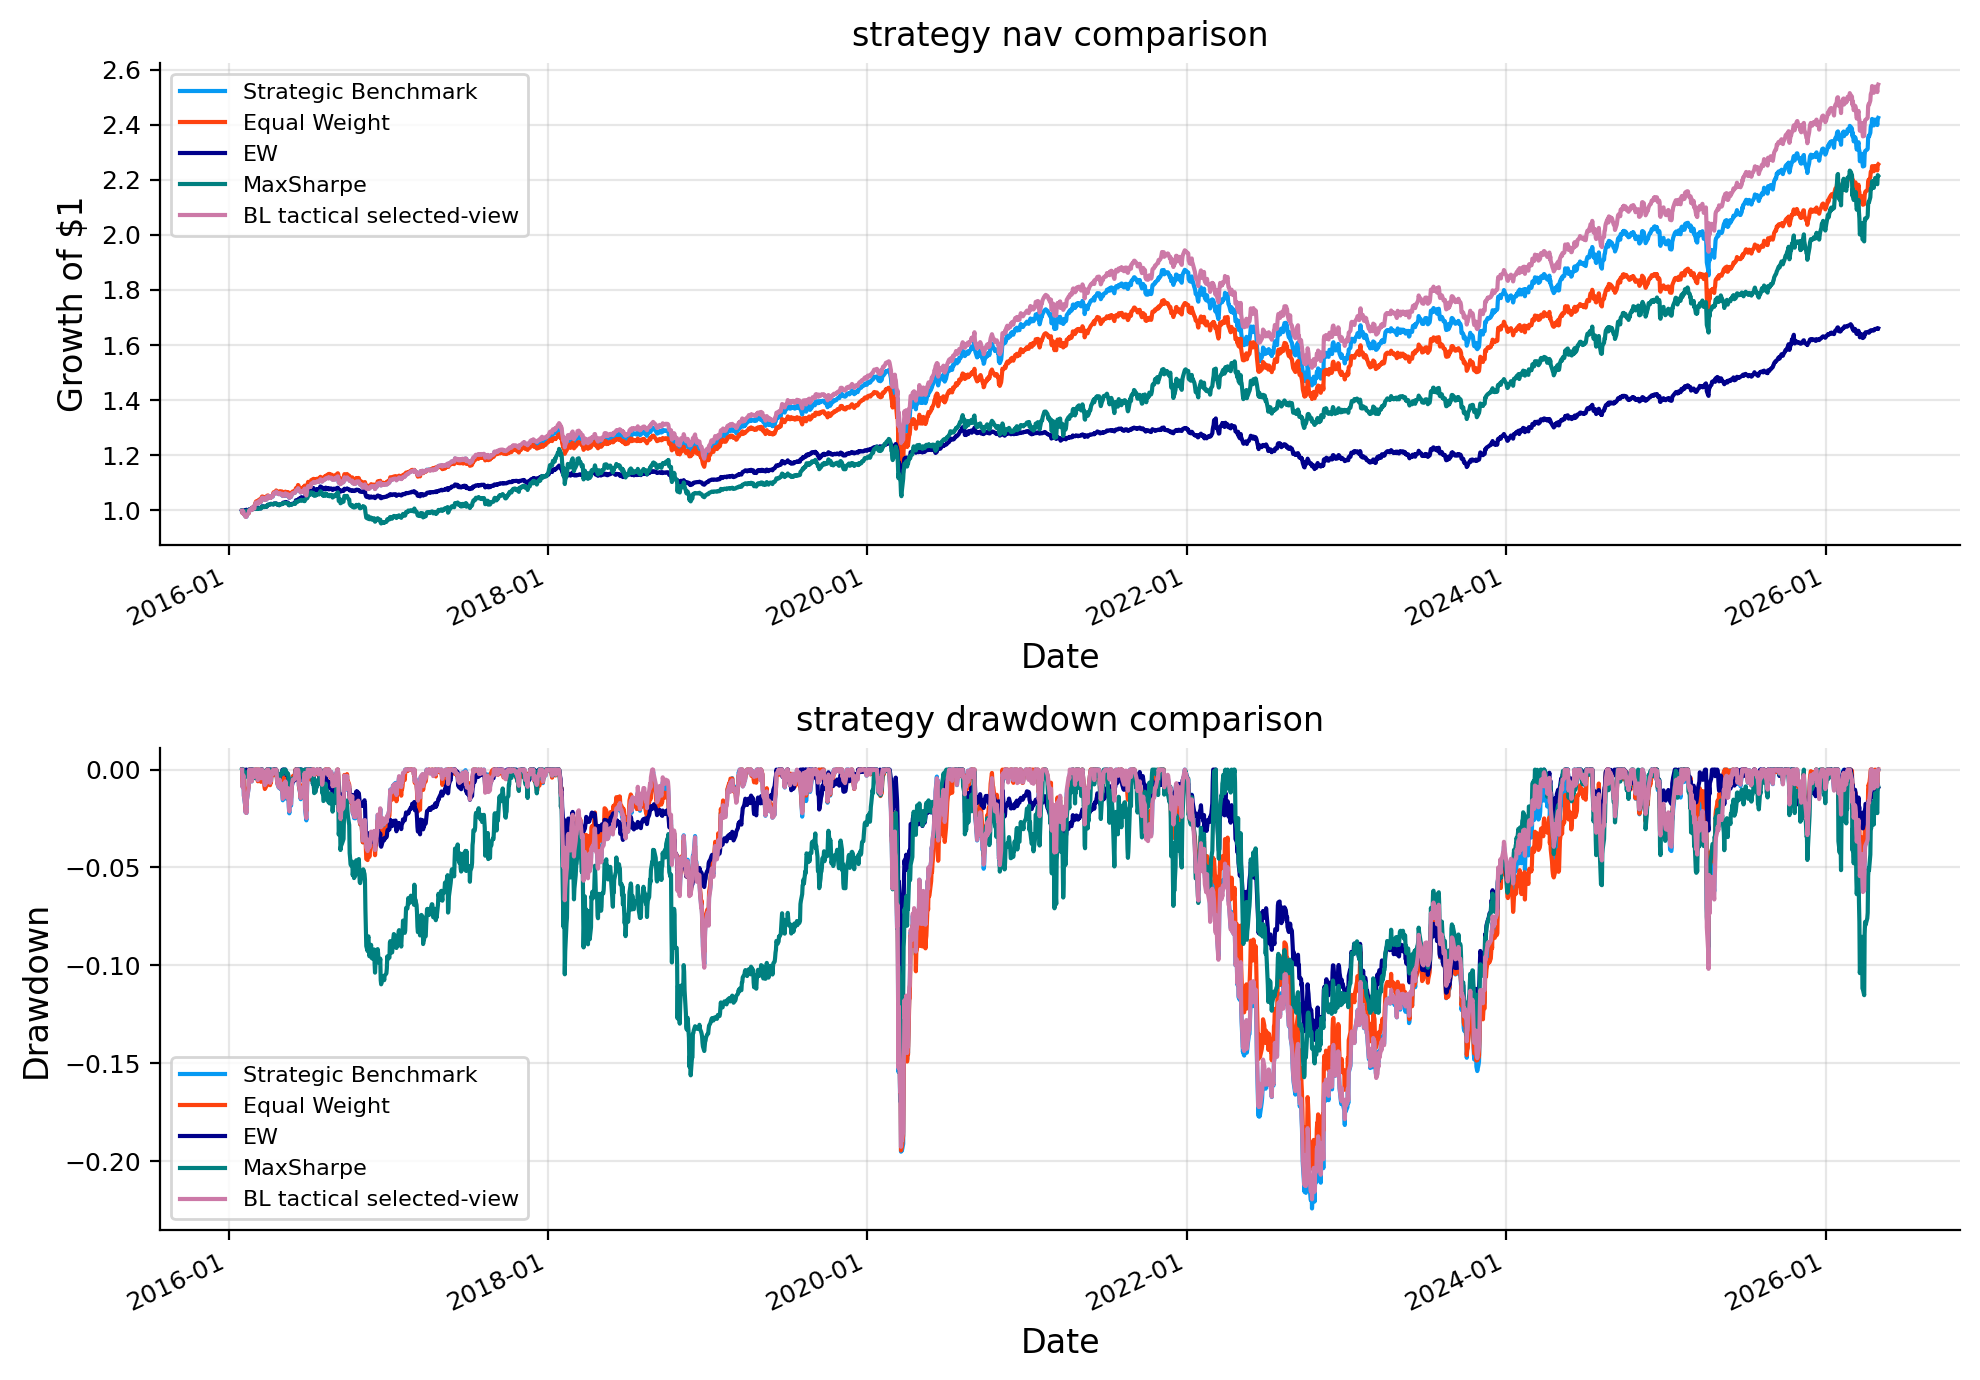

In [28]:
nav_df = pd.DataFrame(nav_by_strategy)[final_strategy_names]
drawdown_df = nav_df / nav_df.cummax() - 1.0
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
plot_strategy_nav(nav_df, final_strategy_names, ax=axes[0], title="strategy nav comparison")
plot_strategy_drawdowns(nav_df, final_strategy_names, ax=axes[1], title="strategy drawdown comparison")
plt.tight_layout()
plt.show()


,max_dd,longest_dd_days,avg_recovery_days,ulcer_index
object,,,,
BL tactical selected-view,-0.2195,597,11.9563,0.0602
EWMA Momentum MV,-0.1381,516,19.0932,0.0433
Equal Weight,-0.2039,664,14.7086,0.0571
MaxSharpe_FG_EWMA_Mom,-0.1655,497,21.6981,0.0617
Strategic Benchmark,-0.2242,598,12.4830,0.0612


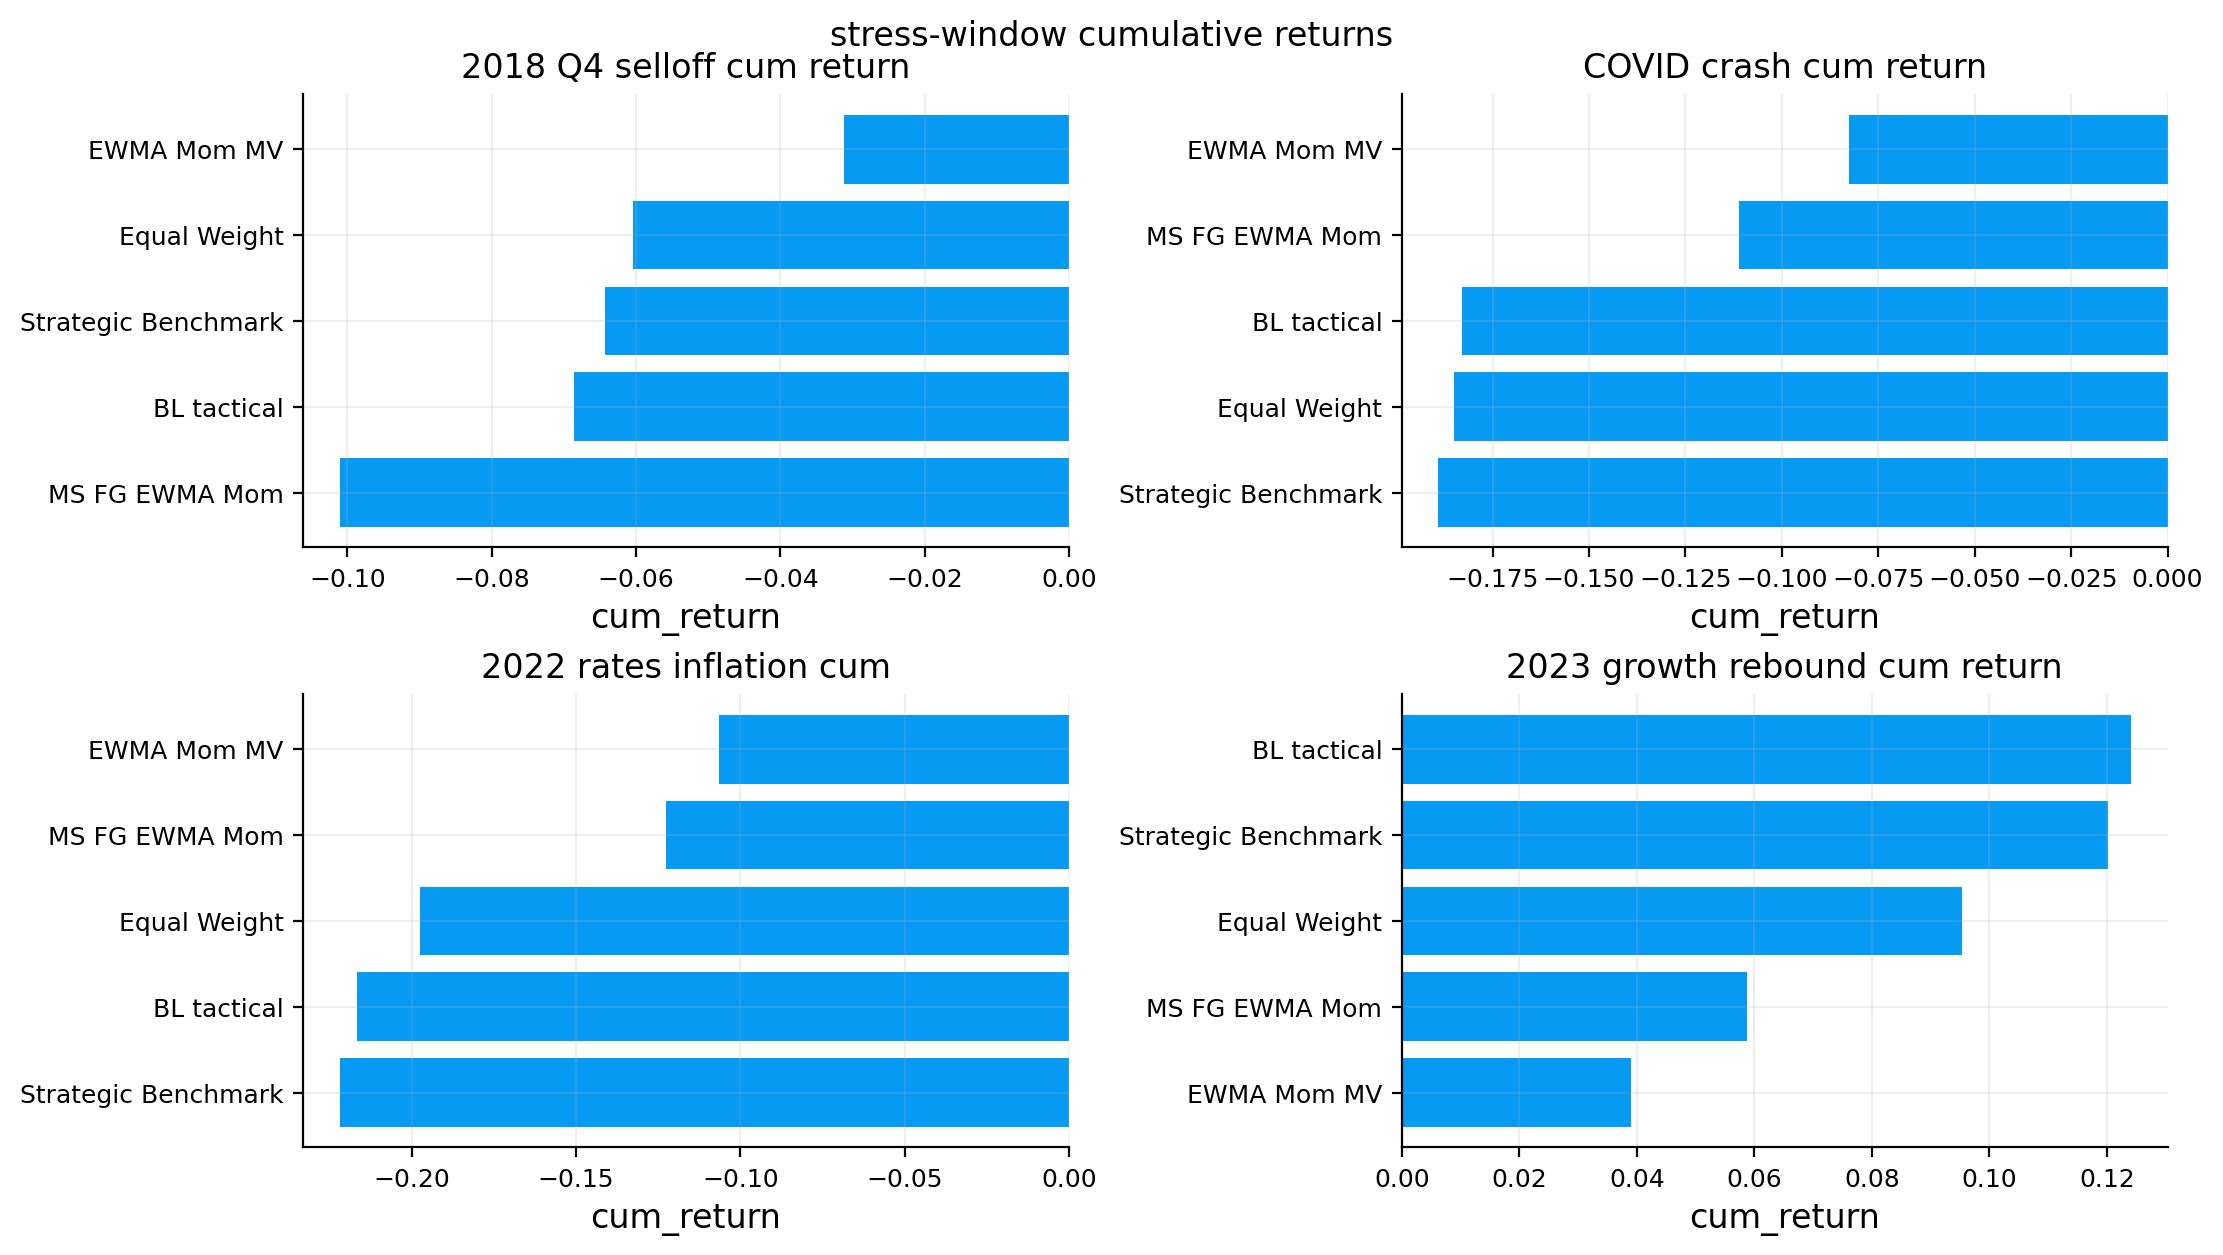

,hist_var5,hist_es5,fhs_var5,fhs_es5
object,,,,
BL tactical selected-view,0.0095,0.0151,0.0110,0.0173
EWMA Momentum MV,0.0054,0.0083,0.0042,0.0065
Equal Weight,0.0085,0.0139,0.0098,0.0151
MaxSharpe_FG_EWMA_Mom,0.0109,0.0178,0.0204,0.0300
Strategic Benchmark,0.0093,0.0151,0.0109,0.0172


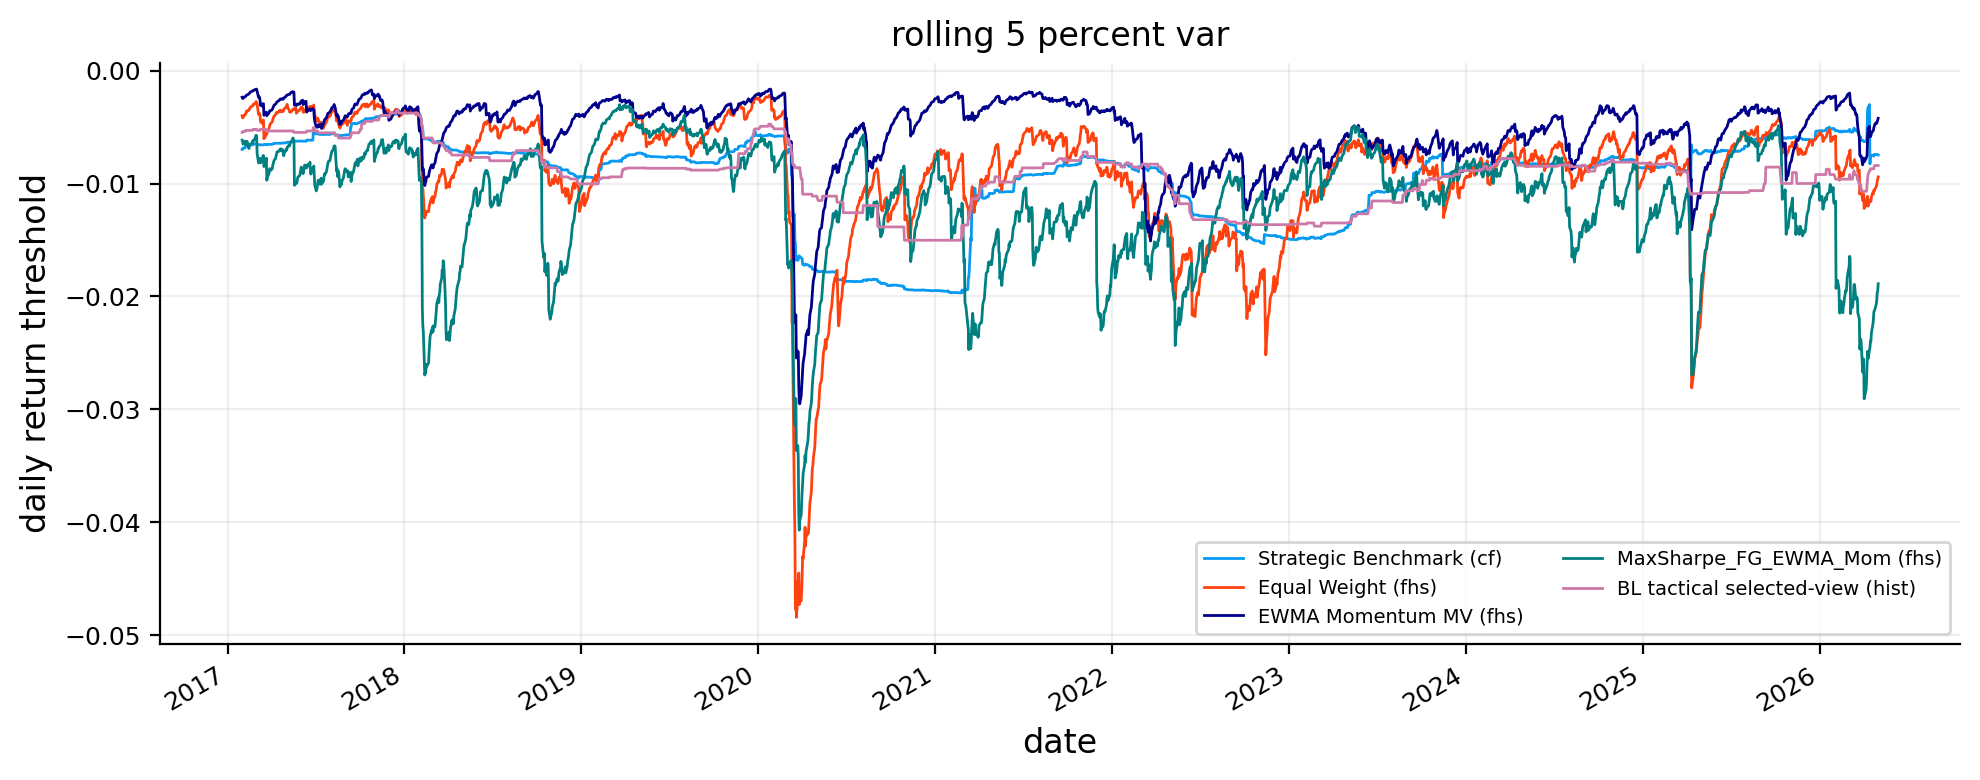

In [29]:
final_returns_df = pd.DataFrame(returns_by_strategy)[final_strategy_names].dropna(how="all").fillna(0.0)

drawdown_summary = drawdown_summary_table(final_returns_df)
if drawdown_summary.empty:
    rows = []
    for name in final_strategy_names:
        nav = simple_nav(final_returns_df[name]); dd = simple_drawdown(nav)
        rows.append({"strategy": name, "max_drawdown": dd.min(), "date_of_max_drawdown": dd.idxmin(), "current_drawdown": dd.iloc[-1], "average_drawdown": dd.mean()})
    drawdown_summary = pd.DataFrame(rows).set_index("strategy")
display(drawdown_summary.round(4))

stress_windows = {"2018_Q4_selloff": ("2018-10-01", "2018-12-31"), "COVID_crash": ("2020-02-19", "2020-03-23"), "2022_rates_inflation": ("2022-01-03", "2022-10-14"), "2023_growth_rebound": ("2023-01-01", "2023-07-31")}
stress_result = stress_table(final_returns_df, windows=stress_windows, worst_only=False)
fig, axes = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True)
for ax, window in zip(axes.ravel(), stress_windows.keys()):
    plot_stress_bar(ax, stress_result, window=window, metric="cum_return", ascending=True)
fig.suptitle("stress-window cumulative returns", y=1.02)
plt.show()

var_es = var_es_table(final_returns_df, alpha=0.05, methods=("hist", "fhs"))
display(var_es.round(4))

best_var_method = {name: "fhs" for name in final_strategy_names}
var_backtest_internal = var_backtest_table(final_returns_df, alpha=0.05, methods=("hist", "cf", "fhs"), lookback=252)
picked = best_var_methods(var_backtest_internal)
if isinstance(picked, dict):
    best_var_method.update({k: picked.get(k, "fhs") for k in final_strategy_names})

fig, ax = plt.subplots(figsize=(10, 4))
for name in final_strategy_names:
    method = best_var_method.get(name, "fhs")
    method = method if method in ["hist", "cf", "fhs"] else "fhs"
    rv = rolling_var(final_returns_df[name], alpha=0.05, lookback=252, method=method)
    rv.plot(ax=ax, lw=1.0, label=f"{name} ({method})")
    
ax.set_title("rolling 5 percent var"); ax.set_ylabel("daily return threshold"); ax.set_xlabel("date"); ax.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()


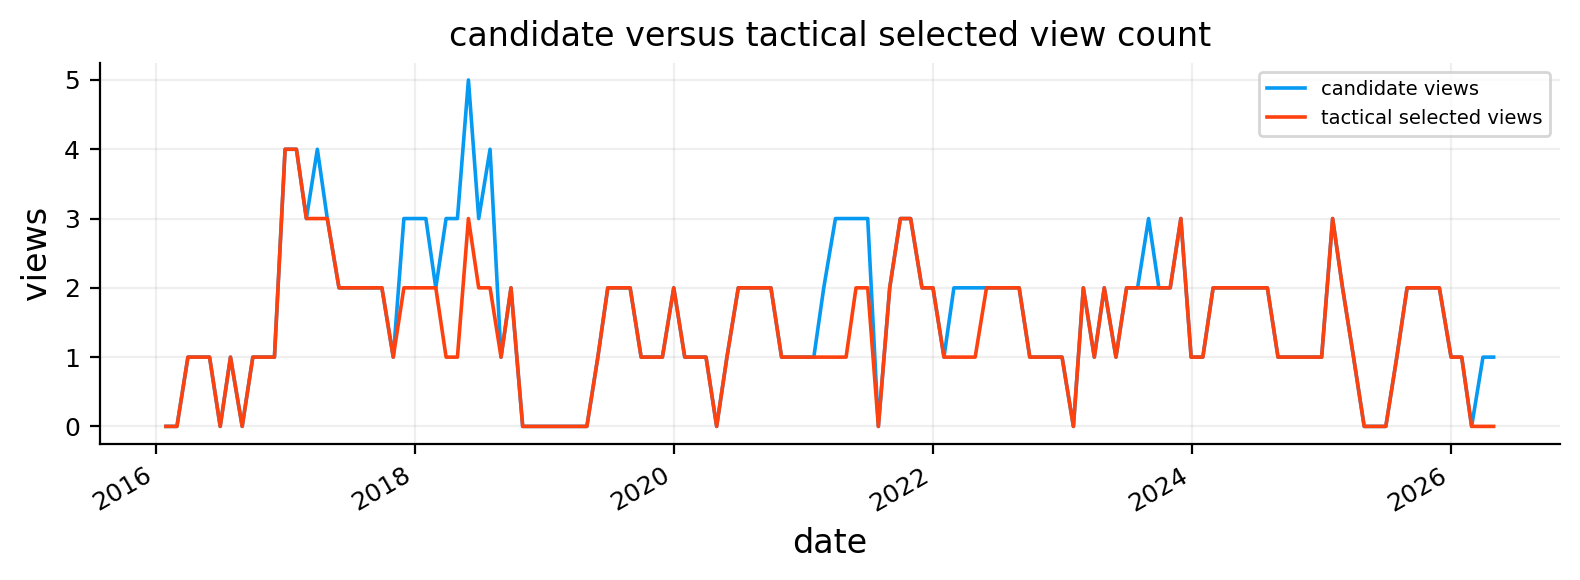

,,candidate_count,kept_share,avg_confidence,avg_selected_score,avg_hit_rate,avg_payoff_ir
economic_theme,view_family,,,,,,
equity_duration,equity_duration_risk_on,69,1.0000,0.6798,1.1758,0.8168,0.5154
growth_leadership,growth_leadership,4,1.0000,0.4700,1.1568,1.0000,2.1017
inflation_duration,inflation_vs_duration,32,0.6250,0.3792,0.9844,0.4467,-0.0161
credit_confirmation,credit_risk_confirmation,3,1.0000,0.4067,0.9315,1.0000,2.1614
quality_vs_cyclicals,large_quality_vs_cyclicals,51,1.0000,0.5852,0.9005,0.6649,0.3502
duration_recovery,duration_recovery,12,1.0000,0.4507,0.7068,0.5449,0.3535
short_duration,short_duration_bond_defense,28,0.6071,0.3215,0.6220,0.3892,-0.0952


,date,view_family,economic_theme,view_name,economic_label,long_assets,short_assets,signal_value,q_tilt,q_tilt_final,q,risk_orientation
172,2026-01-30,equity_duration_risk_on,equity_duration,equity leaders over duration,equity risk-on leadership versus duration,[SPY],[TLT],0.7473,0.035,0.035,0.0669,risk_on


,active_count,share_of_rebalance_dates,avg_abs_q,avg_signal_strength
view_family,,,,
equity_duration_risk_on,69,0.5565,0.0322,1.3211
large_quality_vs_cyclicals,51,0.4113,0.0214,0.9388
inflation_vs_duration,18,0.1452,0.0132,1.5786
short_duration_bond_defense,16,0.1290,0.0092,0.7750
duration_recovery,12,0.0968,0.0085,0.7079
growth_leadership,4,0.0323,0.0052,1.0679
credit_risk_confirmation,3,0.0242,0.0019,0.8562


In [30]:
candidate_active_count = candidate_view_log.groupby("date").size().reindex(rebalance_dates[:-1], fill_value=0) if not candidate_view_log.empty else pd.Series(0, index=rebalance_dates[:-1])
tactical_active_count = selected_view_log.groupby("date").size().reindex(rebalance_dates[:-1], fill_value=0) if not selected_view_log.empty else pd.Series(0, index=rebalance_dates[:-1])
fig, ax = plt.subplots(figsize=(8, 3))
candidate_active_count.plot(ax=ax, lw=1.3, label="candidate views")
tactical_active_count.plot(ax=ax, lw=1.3, label="tactical selected views")
ax.set_title("candidate versus tactical selected view count")
ax.set_ylabel("views")
ax.set_xlabel("date")
ax.legend()
plt.tight_layout(); plt.show()

if not selection_log.empty:
    selection_summary = selection_log.groupby(["economic_theme", "view_family"]).agg(
        candidate_count=("view_name", "size"),
        kept_share=("kept", "mean"),
        avg_confidence=("confidence", "mean"),
        avg_selected_score=("selected_score", "mean"),
        avg_hit_rate=("hit_rate", "mean"),
        avg_payoff_ir=("payoff_ir", "mean"),
    ).sort_values(["avg_selected_score", "candidate_count"], ascending=[False, False])
    display(selection_summary.round(4))

if not selected_view_log.empty:
    latest_view_date = selected_view_log["date"].max()
    latest_views_table = selected_view_log[selected_view_log["date"] == latest_view_date][["date", "view_family", "economic_theme", "view_name", "economic_label", "long_assets", "short_assets", "signal_value", "q_tilt", "q_tilt_final", "q", "risk_orientation"]]
    display(latest_views_table.round(4))
    view_frequency_table = selected_view_log.groupby("view_family").agg(active_count=("view_name", "size"), share_of_rebalance_dates=("date", lambda x: x.nunique() / len(rebalance_dates[:-1])), avg_abs_q=("q_tilt_final", lambda x: np.mean(np.abs(x))), avg_signal_strength=("signal_value", lambda x: np.mean(np.abs(x)))).sort_values("active_count", ascending=False)
    display(view_frequency_table.round(4))
else:
    print("no tactical selected views were active")


,asset,benchmark_weight,prior_mu,post_mu_prior_only,post_mu_tactical,posterior_shift_tactical
0,SPY,0.2222,0.1142,0.1142,0.1142,0.0
1,QQQ,0.0808,0.1406,0.1406,0.1406,0.0
2,IWM,0.0404,0.1526,0.1526,0.1526,0.0
3,EFA,0.0909,0.1602,0.1602,0.1602,0.0
4,EEM,0.0505,0.2100,0.2100,0.2100,0.0
5,TLT,0.0808,0.0394,0.0394,0.0394,0.0
6,IEF,0.0808,0.0263,0.0263,0.0263,0.0
7,SHY,0.0505,0.0079,0.0079,0.0079,0.0
8,AGG,0.1010,0.0241,0.0241,0.0241,0.0
9,LQD,0.0505,0.0360,0.0360,0.0360,0.0


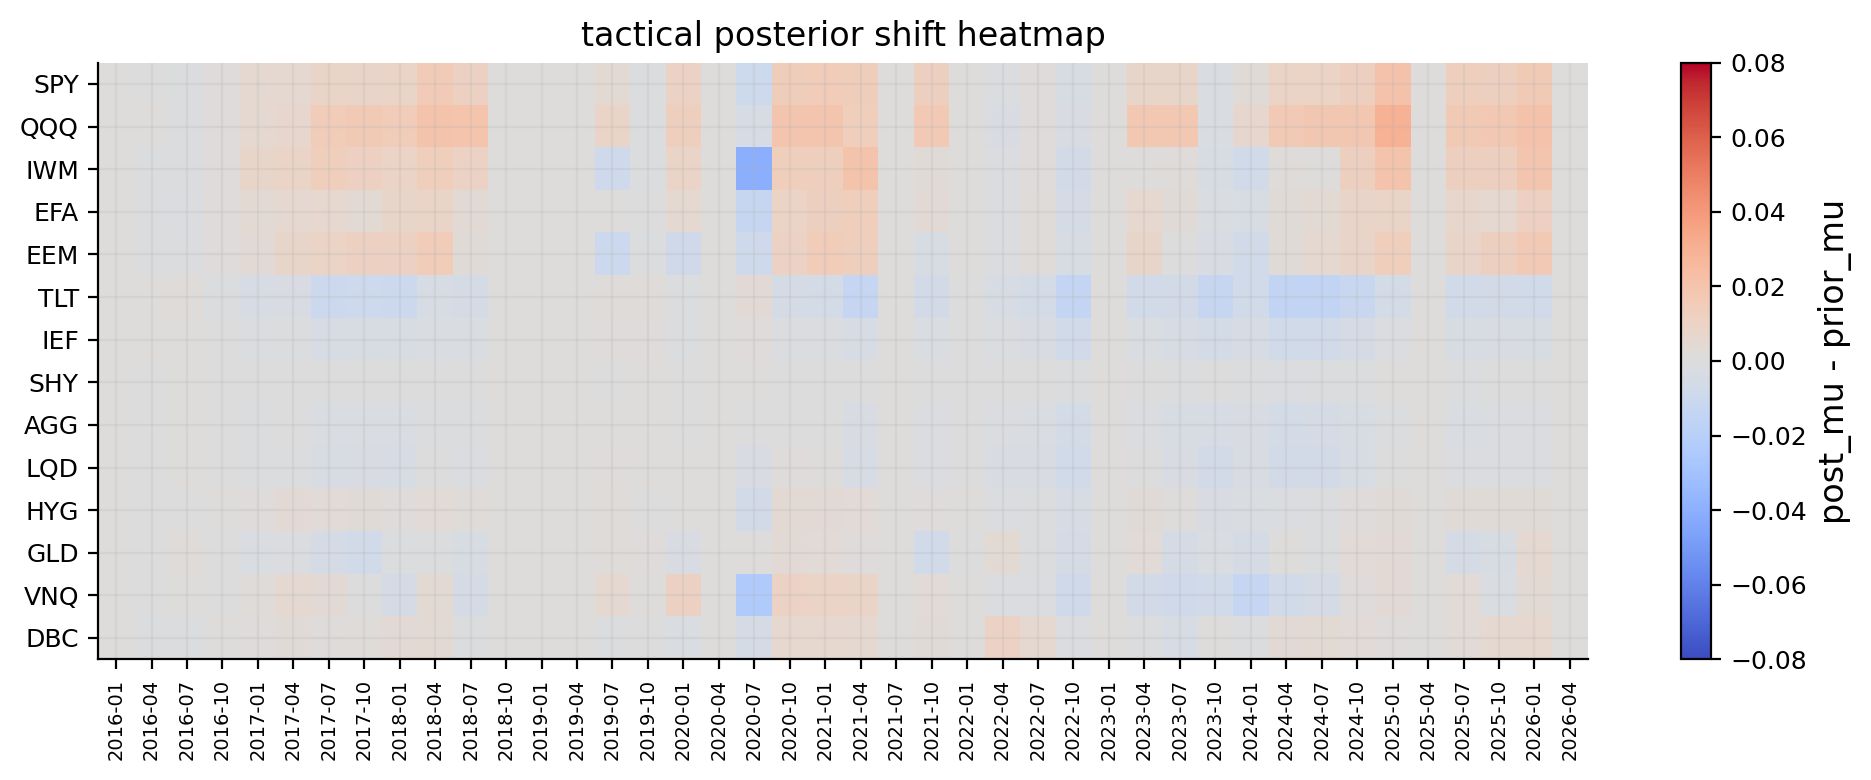

In [31]:
latest_post_date = posterior_log["date"].max() if not posterior_log.empty else pd.Timestamp(rebalance_dates[-2])
prior_latest = prior_mu_by_date[pd.Timestamp(latest_post_date)].reindex(assets)
posterior_clarity = pd.DataFrame({
    "asset": assets,
    "benchmark_weight": benchmark_w.reindex(assets).values,
    "prior_mu": prior_latest.values,
    "post_mu_prior_only": post_mu_store.get(("BL prior-only", latest_post_date), prior_latest).reindex(assets).values,
    "post_mu_tactical": post_mu_store.get(("BL tactical selected-view", latest_post_date), prior_latest).reindex(assets).values,
})
posterior_clarity["posterior_shift_tactical"] = posterior_clarity["post_mu_tactical"] - posterior_clarity["prior_mu"]
display(posterior_clarity.round(4))
shift_cols = {}
for dt in sorted({key[1] for key in post_mu_store if key[0] == "BL tactical selected-view"}):
    shift_cols[dt] = post_mu_store[("BL tactical selected-view", dt)].reindex(assets) - prior_mu_by_date[dt].reindex(assets)
tactical_shift = pd.DataFrame(shift_cols)
if not tactical_shift.empty:
    selected_shift = tactical_shift.iloc[:, ::max(1, tactical_shift.shape[1] // 36)]
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(selected_shift, aspect="auto", cmap="coolwarm", vmin=-0.08, vmax=0.08)
    ax.set_title("tactical posterior shift heatmap")
    ax.set_yticks(range(len(selected_shift.index)), selected_shift.index)
    ax.set_xticks(range(len(selected_shift.columns)), [d.strftime("%Y-%m") for d in selected_shift.columns], rotation=90, fontsize=7)
    fig.colorbar(im, ax=ax, label="post_mu - prior_mu")
    plt.tight_layout(); plt.show()


In [32]:
if not candidate_view_log.empty:
    candidate_counts = candidate_view_log.groupby("view_family").size().rename("candidate_count")
    econ_label = candidate_view_log.groupby("view_family")["economic_label"].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
    risk_mode = candidate_view_log.groupby("view_family")["risk_orientation"].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
else:
    candidate_counts = pd.Series(dtype=float, name="candidate_count"); econ_label = pd.Series(dtype=object); risk_mode = pd.Series(dtype=object)
if not selected_view_log.empty:
    selected_counts = selected_view_log.groupby("view_family").size().rename("selected_count")
    avg_abs_q = selected_view_log.groupby("view_family")["q_tilt_final"].agg(lambda x: np.mean(np.abs(x))).rename("avg_abs_q")
else:
    selected_counts = pd.Series(dtype=float, name="selected_count"); avg_abs_q = pd.Series(dtype=float, name="avg_abs_q")
if not all_payoff_history.empty:
    payoff_stats = all_payoff_history.groupby("view_family").agg(hit_rate=("hit", "mean"), avg_payoff=("payoff", "mean"), payoff_vol=("payoff", "std"))
    payoff_stats["payoff_ir"] = payoff_stats["avg_payoff"] / payoff_stats["payoff_vol"].replace(0.0, np.nan)
    recent_hits = all_payoff_history.sort_values("date").groupby("view_family").tail(6).groupby("view_family")["hit"].mean().rename("recent_hit_rate")
else:
    payoff_stats = pd.DataFrame(columns=["hit_rate", "avg_payoff", "payoff_vol", "payoff_ir"]); recent_hits = pd.Series(dtype=float, name="recent_hit_rate")
conf_means = confidence_log.groupby("view_family")["confidence"].mean().rename("avg_tactical_confidence") if not confidence_log.empty else pd.Series(dtype=float)
score_means = confidence_log.groupby("view_family")["selected_score"].mean().rename("avg_selected_score") if not confidence_log.empty and "selected_score" in confidence_log.columns else pd.Series(dtype=float)
reliability = pd.concat([candidate_counts, selected_counts, econ_label.rename("economic_label"), payoff_stats, avg_abs_q, conf_means, score_means, recent_hits, risk_mode.rename("risk_orientation_mode")], axis=1)
reliability["selected_share"] = reliability["selected_count"] / reliability["candidate_count"].replace(0.0, np.nan)

def reliability_label(row):
    count = row.get("candidate_count", 0); hit_rate = row.get("hit_rate", np.nan); payoff_ir = row.get("payoff_ir", np.nan); risk = row.get("risk_orientation_mode", "neutral")
    if count < 10:
        return "low evidence"
    if np.isfinite(payoff_ir) and np.isfinite(hit_rate) and payoff_ir > 0 and hit_rate > 0.55:
        return "reliable positive"
    if (np.isfinite(hit_rate) and hit_rate < 0.45) or (np.isfinite(payoff_ir) and payoff_ir < 0):
        return "unstable"
    if risk == "risk_off":
        return "mostly defensive"
    if risk == "risk_on":
        return "mostly risk-on"
    return "mixed but useful"

def final_reliability_decision(row):
    count = row.get("candidate_count", 0)
    selected_count = row.get("selected_count", 0)
    hit_rate = row.get("hit_rate", np.nan)
    payoff_ir = row.get("payoff_ir", np.nan)
    recent_hit_rate = row.get("recent_hit_rate", np.nan)
    if np.isfinite(recent_hit_rate) and recent_hit_rate < 0.30 and count >= 8:
        return "drop when recent weak"
    if np.isfinite(hit_rate) and np.isfinite(payoff_ir) and hit_rate < 0.45 and payoff_ir < 0:
        return "drop when active"
    if count < 10:
        return "low evidence, small q"
    if selected_count > 0 and np.isfinite(hit_rate) and np.isfinite(payoff_ir) and hit_rate > 0.55 and payoff_ir > 0:
        return "keep"
    if selected_count > 0:
        return "keep but monitor"
    return "candidate only"

reliability["interpretation"] = reliability.apply(reliability_label, axis=1)
reliability["final_decision"] = reliability.apply(final_reliability_decision, axis=1)
reliability = reliability[["economic_label", "candidate_count", "selected_count", "selected_share", "hit_rate", "avg_payoff", "payoff_vol", "payoff_ir", "avg_abs_q", "avg_tactical_confidence", "avg_selected_score", "recent_hit_rate", "risk_orientation_mode", "interpretation", "final_decision"]].sort_values(["selected_count", "candidate_count"], ascending=False)
display(reliability.round(4))


,economic_label,candidate_count,selected_count,selected_share,hit_rate,avg_payoff,payoff_vol,payoff_ir,avg_abs_q,avg_tactical_confidence,avg_selected_score,recent_hit_rate,risk_orientation_mode,interpretation,final_decision
view_family,,,,,,,,,,,,,,,
equity_duration_risk_on,equity risk-on leadership versus duration,69,69,1.0000,0.7246,0.1971,0.5136,0.3837,0.0322,0.6798,1.1758,0.6667,risk_on,reliable positive,keep
large_quality_vs_cyclicals,large liquid equity versus cyclical risk assets,51,51,1.0000,0.6275,0.0991,0.4244,0.2335,0.0214,0.5852,0.9005,0.5000,risk_on,reliable positive,keep
inflation_vs_duration,commodity inflation pressure versus duration b...,32,18,0.5625,0.4839,0.0959,0.6809,0.1408,0.0132,0.4645,1.0711,0.3333,neutral,mixed but useful,keep but monitor
short_duration_bond_defense,short-duration bond defense versus duration,28,16,0.5714,0.4286,-0.0181,0.4171,-0.0435,0.0092,0.4014,0.7088,0.3333,risk_off,unstable,drop when active
duration_recovery,duration recovery versus short bills,12,12,1.0000,0.5833,0.1868,0.4846,0.3856,0.0085,0.4507,0.7068,0.6667,risk_off,reliable positive,keep
growth_leadership,growth leadership versus broad US equity,4,4,1.0000,0.7500,0.0842,0.2928,0.2875,0.0052,0.4700,1.1568,0.7500,risk_on,low evidence,"low evidence, small q"
credit_risk_confirmation,confirmed credit risk appetite,3,3,1.0000,0.6667,0.0257,0.1915,0.1344,0.0019,0.4067,0.9315,0.6667,risk_on,low evidence,"low evidence, small q"


In [33]:
decision_table = reliability[["candidate_count", "selected_count", "selected_share", "hit_rate", "payoff_ir", "recent_hit_rate", "avg_tactical_confidence", "avg_selected_score", "risk_orientation_mode", "interpretation", "final_decision"]].copy()
display(decision_table.round(4))
if not selection_log.empty:
    selection_reason_table = selection_log.groupby("scale_reason").size().rename("count").sort_values(ascending=False).to_frame()
    selection_reason_table["share"] = selection_reason_table["count"] / selection_reason_table["count"].sum()
    display(selection_reason_table.round(4))


,candidate_count,selected_count,selected_share,hit_rate,payoff_ir,recent_hit_rate,avg_tactical_confidence,avg_selected_score,risk_orientation_mode,interpretation,final_decision
view_family,,,,,,,,,,,
equity_duration_risk_on,69,69,1.0000,0.7246,0.3837,0.6667,0.6798,1.1758,risk_on,reliable positive,keep
large_quality_vs_cyclicals,51,51,1.0000,0.6275,0.2335,0.5000,0.5852,0.9005,risk_on,reliable positive,keep
inflation_vs_duration,32,18,0.5625,0.4839,0.1408,0.3333,0.4645,1.0711,neutral,mixed but useful,keep but monitor
short_duration_bond_defense,28,16,0.5714,0.4286,-0.0435,0.3333,0.4014,0.7088,risk_off,unstable,drop when active
duration_recovery,12,12,1.0000,0.5833,0.3856,0.6667,0.4507,0.7068,risk_off,reliable positive,keep
growth_leadership,4,4,1.0000,0.7500,0.2875,0.7500,0.4700,1.1568,risk_on,low evidence,"low evidence, small q"
credit_risk_confirmation,3,3,1.0000,0.6667,0.1344,0.6667,0.4067,0.9315,risk_on,low evidence,"low evidence, small q"


,count,share
scale_reason,,
kept,176,0.8844
weak family evidence,13,0.0653
recent hit too low,10,0.0503


,asset,active_weight_tactical
0,LQD,-0.0192
1,IEF,-0.0192
2,QQQ,-0.0160
3,GLD,-0.0021
4,IWM,-0.0017
5,VNQ,-0.0006
6,EFA,-0.0005
7,HYG,-0.0000
8,AGG,-0.0000
9,EEM,0.0007


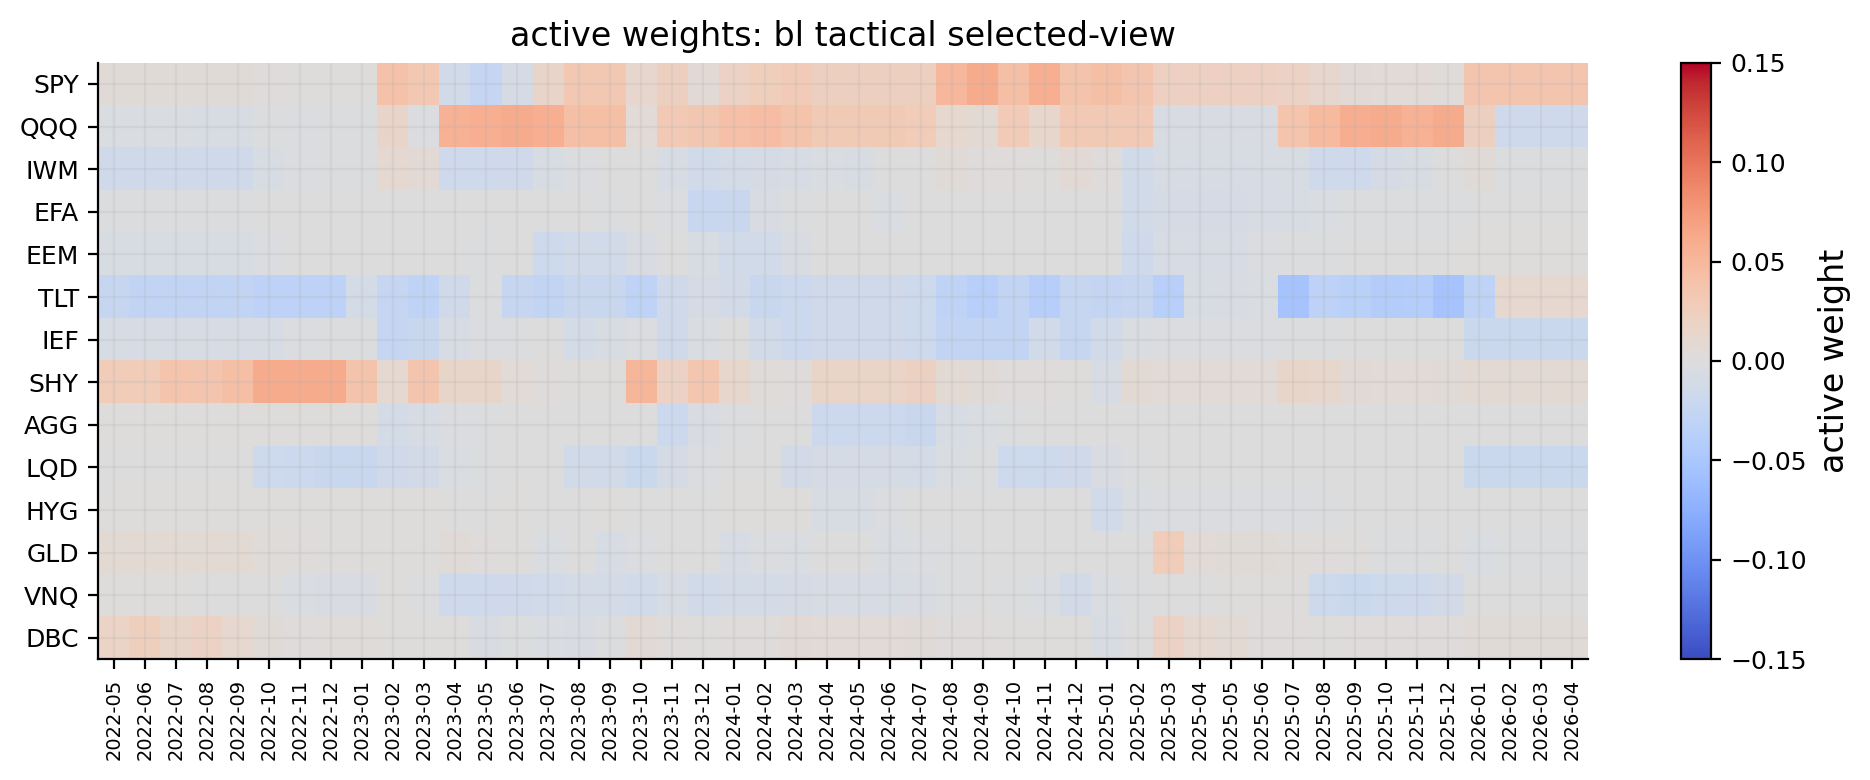

In [34]:
tactical_weights = combined_results["BL tactical selected-view"]["weights"].reindex(columns=assets)
benchmark_aligned = benchmark_w.reindex(assets).fillna(0.0)
active_w_tactical = tactical_weights.subtract(benchmark_aligned, axis=1)
latest_active_w = active_w_tactical.iloc[-1].sort_values()
display(pd.DataFrame({"asset": latest_active_w.index, "active_weight_tactical": latest_active_w.values}).round(4))

frame = active_w_tactical.iloc[-48:].T
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(frame, aspect="auto", cmap="coolwarm", vmin=-0.15, vmax=0.15)
ax.set_title("active weights: bl tactical selected-view")
ax.set_yticks(range(len(frame.index)), frame.index)
ax.set_xticks(range(len(frame.columns)), [d.strftime("%Y-%m") for d in frame.columns], rotation=90, fontsize=7)
fig.colorbar(im, ax=ax, label="active weight")
plt.tight_layout(); plt.show()


In [35]:
def active_risk_series(weights):
    rows = []
    for dt, row in weights.iterrows():
        dt = pd.Timestamp(dt)
        if dt not in cov_by_date:
            continue
        diff = row.reindex(assets).fillna(0.0).values - benchmark_aligned.values
        cov_ann = cov_by_date[dt].loc[assets, assets].values
        rows.append((dt, float(np.sqrt(max(diff @ cov_ann @ diff, 0.0)))))
    return pd.Series(dict(rows)).sort_index()

active_diagnostics = pd.DataFrame({
    "avg_active_risk": {
        "BL prior-only": active_risk_series(combined_results["BL prior-only"]["weights"].reindex(columns=assets)).mean(),
        "BL tactical selected-view": active_risk_series(combined_results["BL tactical selected-view"]["weights"].reindex(columns=assets)).mean(),
    },
    "avg_turnover": {
        "BL prior-only": combined_results["BL prior-only"]["turnover"].mean(),
        "BL tactical selected-view": combined_results["BL tactical selected-view"]["turnover"].mean(),
    },
})
display(active_diagnostics.round(4))

if "risk_control_log" in globals() and not risk_control_log.empty:
    risk_control_summary = pd.DataFrame({
        "adjusted_share": risk_control_log.groupby("strategy")["risk_control_adjusted"].mean(),
        "avg_alpha": risk_control_log.groupby("strategy")["risk_control_alpha"].mean(),
        "avg_active_distance_before": risk_control_log.groupby("strategy")["active_distance_before"].mean(),
        "avg_active_distance_after": risk_control_log.groupby("strategy")["active_distance_after"].mean(),
        "avg_active_risk_before": risk_control_log.groupby("strategy")["active_risk_before"].mean(),
        "avg_active_risk_after": risk_control_log.groupby("strategy")["active_risk_after"].mean(),
    })
    display(risk_control_summary.round(4))


,avg_active_risk,avg_turnover
BL prior-only,0.0000,0.0144
BL tactical selected-view,0.0072,0.0350


,adjusted_share,avg_alpha,avg_active_distance_before,avg_active_distance_after,avg_active_risk_before,avg_active_risk_after
strategy,,,,,,
BL tactical selected-view,0.6935,0.6724,0.2742,0.1207,0.0161,0.0072
